## Imports and Packages Used

In [73]:
# rdkit things
from rdkit import Chem
from rdkit.Chem import GetPeriodicTable
from rdkit.Chem import rdChemReactions
from rdkit.Chem import Draw
from rdkit.Chem.Draw import ReactionToImage
from rdkit.Chem.Draw import MolToImage
from rdkit.Chem import AllChem
from rdkit import RDLogger
RDLogger.DisableLog("rdApp.*")

# reaction categories for transformer
from tdc.utils import get_reaction_type

# standard libraries
import os
import pickle
import math
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import copy 
from tqdm import tqdm

# machine learning libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
from torch_geometric.nn import global_mean_pool, GINEConv

# GNN (PyTorch Geometric)
from torch_geometric.data import Data as PyGData
from torch_geometric.loader import DataLoader as GraphDataLoader

# Transformer (PyTorch) 
from torch.utils.data import Dataset as TorchDataset
from torch.utils.data import DataLoader as TorchDataLoader
from torch.utils.data import WeightedRandomSampler

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.model_selection import KFold
from sklearn.metrics import f1_score, confusion_matrix, ConfusionMatrixDisplay, accuracy_score
from sklearn.utils.class_weight import compute_class_weight

# used to explore hyperparameter space
from sklearn.experimental import enable_halving_search_cv # needed for HalvingRandomSearch import
from sklearn.model_selection import HalvingRandomSearchCV
from sklearn.base import BaseEstimator, ClassifierMixin
from scipy.stats import uniform, loguniform, randint

# the pain and suffering of a mac user
device = "mps" if torch.backends.mps.is_available() else "cpu"


### (1) Retrieve the cleaned data from data_exploration.ipynb to use in our model. 
Structure it to use in model.

In [74]:
alchemy_elements = {'C', 'Cl', 'F', 'H', 'N', 'O', 'S'}
molecule_types_df = pd.read_pickle("/Users/joshuahoang/Documents/Chem-C242-Final-Project-Organic-Reactions/Collected Data/Alchemy-v20191129/final_version_with_smiles_coords_angles.pkl")
reaction_types_df = pd.read_csv("/Users/joshuahoang/Documents/Chem-C242-Final-Project-Organic-Reactions/Collected Data/uspto_50k_processed.csv")
display(molecule_types_df)
display(reaction_types_df)

,gdb_idx,atom number,"zpve\n(Ha, zero point vibrational energy)","Cv\n(cal/molK, heat capacity at 298.15 K)","gap\n(Ha, LUMO-HOMO)","G\n(Ha, Free energy at 298.15 K)","HOMO\n(Ha, energy of HOMO)","U\n(Ha, internal energy at 298.15 K)","alpha\n(a_0^3, Isotropic polarizability)","U0\n(Ha, internal energy at 0 K)","H\n(Ha, enthalpy at 298.15 K)","LUMO\n(Ha, energy of LUMO)","mu\n(D, dipole moment)","R2\n(a_0^2, electronic spatial extent)",smiles,coords,node_angles
0,2859833,9,0.226164,0.000067,0.300531,-352.128828,-0.236722,-352.076085,99.201621,-352.088194,-352.075141,0.063809,0.180558,1919.249225,CC#CC[C@H](C)CCC,"[[1.4191, 1.0679, -0.7249], [0.642, 0.2423, -1...","{0: [], 1: [1.995018720626831], 2: [2.02745819..."
1,3148292,9,0.180782,0.000058,0.293098,-386.820766,-0.241536,-386.774917,84.670738,-386.784878,-386.773973,0.051562,1.302656,1420.242859,C#CC[C@@H]1CO[C@@H]1CC,"[[0.8276, 0.4718, 0.3516], [0.3443, -0.9649, 0...","{0: [], 1: [1.9479340314865112], 2: [1.9565199..."
2,3607838,9,0.205922,0.000057,0.307544,-388.062328,-0.224965,-388.018758,86.198178,-388.028208,-388.017814,0.082579,1.284923,1257.238492,CC[C@H]1[C@H]2CCO[C@]21C,"[[1.1241, 1.687, -0.1877], [0.1225, 0.564, -0....","{0: [], 1: [1.9696639776229858], 2: [2.1605758..."
3,9540153,11,0.160845,0.000056,0.195923,-515.046508,-0.203538,-515.001198,95.801267,-515.010568,-515.000254,-0.007615,4.074910,1600.220066,COc1nccc2c1OCC2,"[[-5.1197, 7.1633, 5.3178], [-4.7619, 6.1363, ...","{0: [], 1: [2.1072568893432617], 2: [1.9805861..."
4,340363,10,0.177712,0.000057,0.254495,-403.843164,-0.248943,-403.800346,95.147725,-403.809426,-403.799402,0.005552,4.111533,1442.171110,CC1=CC[C@H]2C[C@@H]2[C@H]1C#N,"[[0.4915, 0.3661, 0.231], [0.5473, 0.8513, -1....","{0: [], 1: [2.125312328338623, 2.0248210430145..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
202574,9581016,10,0.120222,0.000051,0.179768,-450.915828,-0.244325,-450.872449,88.581216,-450.881390,-450.871505,-0.064557,6.434535,1541.115465,CNc1cc(C#N)ncn1,"[[1.1884, 0.0204, -0.0006], [0.1768, 0.0285, -...","{0: [], 1: [2.1844115257263184], 2: [2.1464011..."
202575,9706527,10,0.130179,0.000053,0.189401,-438.632624,-0.231340,-438.589755,96.102362,-438.598674,-438.588811,-0.041938,0.338522,1628.839361,C#Cc1ccnc(OC)c1,"[[1.2218, 0.0872, -0.2336], [0.234, 1.1131, -0...","{0: [], 1: [2.0464351177215576], 2: [2.0328996..."
202576,9760179,10,0.119919,0.000051,0.163827,-450.920199,-0.232783,-450.875248,89.074794,-450.884399,-450.874304,-0.068956,4.337358,1497.024559,CNc1nccc(C#N)n1,"[[1.2711, 0.1905, 0.01], [0.3996, -0.033, 1.14...","{0: [], 1: [2.162799835205078], 2: [2.02789354..."
202577,9845175,10,0.119740,0.000050,0.191354,-454.722866,-0.251374,-454.680504,89.026059,-454.689065,-454.679560,-0.060020,5.263580,1611.219983,COc1cncc(C#N)c1,"[[0.733, 0.0993, -0.1025], [1.2403, 0.3389, -1...","{0: [], 1: [2.067808151245117], 2: [2.18707561..."


,reactant,product,category
0,C1=COCCC1.COC(=O)CCC(=O)c1ccc(O)cc1O,COC(=O)CCC(=O)c1ccc(OC2CCCCO2)cc1O,1
1,COC(=O)c1cccc(C(=O)O)c1.Nc1cccnc1N,COC(=O)c1cccc(-c2nc3cccnc3[nH]2)c1,4
2,CC(C)(C)OC(=O)NC1CCC(C(=O)O)CC1.CNOC,CON(C)C(=O)C1CCC(NC(=O)OC(C)(C)C)CC1,2
3,Nc1ccc(O)cc1.O=[N+]([O-])c1ccc(Cl)nc1Cl,O=[N+]([O-])c1ccc(Cl)nc1Nc1ccc(O)cc1,1
4,[N-]=[N+]=NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([...,NCC1=CC[C@@H](c2ccc(Cl)cc2Cl)[C@H]([N+](=O)[O-...,9
...,...,...,...
35111,COC(=O)c1ccc(C(=O)OCc2ccccc2)cc1F,COC(=O)c1ccc(C(=O)O)cc1F,6
35112,C=CCOC(=O)N1CCc2nnc(NN)cc2C1.CC(C)=O,C=CCOC(=O)N1CCc2nnc(NN=C(C)C)cc2C1,1
35113,FC1(F)CCNC1.O=C(O)c1ccncc1NC(=O)c1nc(C2CC2)ccc...,O=C(Nc1cnccc1C(=O)N1CCC(F)(F)C1)c1nc(C2CC2)ccc...,2
35114,CC(=O)Cl.CC(C)(C)OC(=O)NCCO,CC(=O)OCCNC(=O)OC(C)(C)C,2


Pipeline

(a) The GNN will take each molecule as a pooling of the atoms as nodes and the bonds as edges and lets each atom update its features by aggreating from its neighbors. 

(b) After this messaging, pool atoms to molecule to predict the target features that will be used in the decision tree for the reaction type. 

     - 12 columns are physics-relevent feature columns
     - 9/12 of the physics-relevent ones do not have too bad overlap

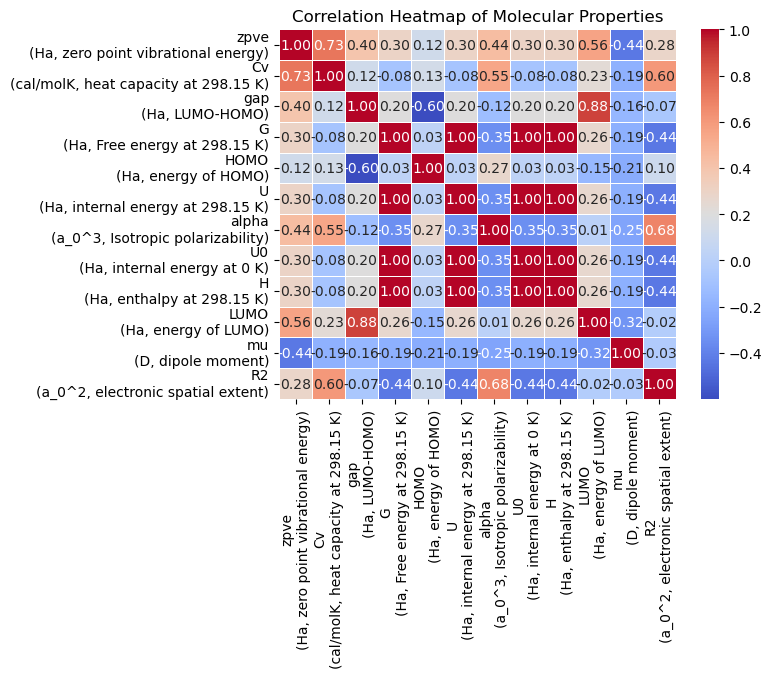

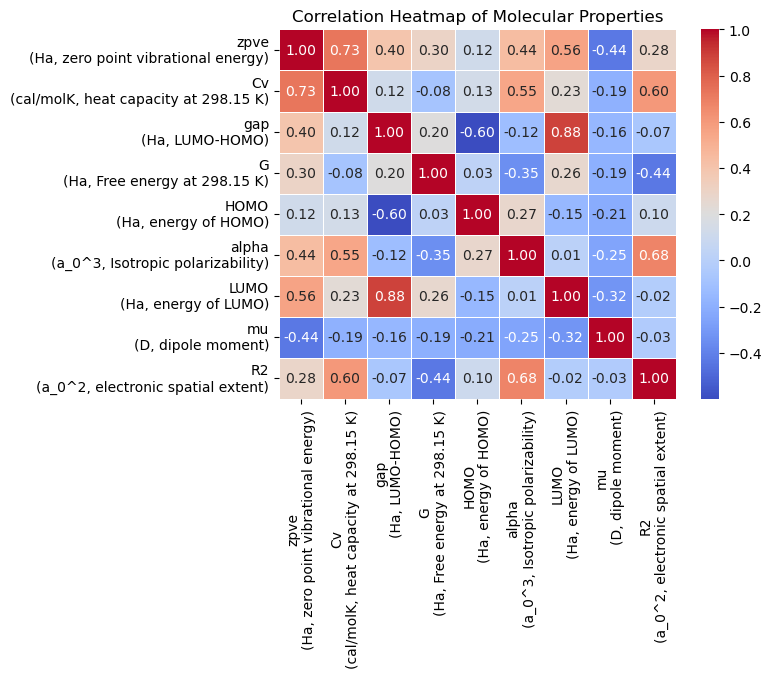

In [75]:
def plot_heatmap(df):
    plt.figure()
    sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap of Molecular Properties")
    plt.show()

# 12 that are physics-relevent target features
molecule_targets_df = molecule_types_df.drop(columns=[
    'smiles', 
    'gdb_idx', 
    'atom number', 
    'coords', 
    'node_angles'
])
plot_heatmap(molecule_targets_df)

# G, U, U0, H: G = U + PV - TS = H - TS, so we only need 1 -> keep G
molecule_targets_df = molecule_types_df.drop(columns=[
    'smiles', 
    'gdb_idx', 
    'atom number', 
    'coords',
    'node_angles',
    'U\n(Ha, internal energy at 298.15 K)',
    'U0\n(Ha, internal energy at 0 K)', 
    'H\n(Ha, enthalpy at 298.15 K)', 
])
plot_heatmap(molecule_targets_df)

### (2) GNN Creation

Turn all the data into a graph structure. We choose the features that help predic the nine properties like bond angle, bond length in the form of RBF (Radial Basis Function) which helps the model learn the importance of distances easiler based on gaussian distribution of distances.

In [76]:
class AlchemyGraphFeaturizer:

    def __init__(self, alchemy_elements, target_cols, max_angles=6, rbf_centers=16):
        self.alchemy_elements = list(alchemy_elements)
        self.target_cols = list(target_cols)
        self.max_angles = max_angles
        self.rbf_centers = rbf_centers

        # discretized features that need to be put into one-hot
        self.degree_set = [0, 1, 2, 3, 4, 5]
        self.numH_set = [0, 1, 2, 3, 4]
        self.charge_set = [-1, 0, 1]
        self.hybridization_set = [
            Chem.rdchem.HybridizationType.SP,
            Chem.rdchem.HybridizationType.SP2,
            Chem.rdchem.HybridizationType.SP3,
            Chem.rdchem.HybridizationType.SP3D,
            Chem.rdchem.HybridizationType.SP3D2,
        ]

        self.bond_types = [
            Chem.rdchem.BondType.SINGLE,
            Chem.rdchem.BondType.DOUBLE,
            Chem.rdchem.BondType.TRIPLE,
            Chem.rdchem.BondType.AROMATIC,
        ]
        self.stereo_types = [
            Chem.rdchem.BondStereo.STEREONONE,
            Chem.rdchem.BondStereo.STEREOZ,
            Chem.rdchem.BondStereo.STEREOE,
        ]

        self.pt = Chem.GetPeriodicTable()
        self.en_map = {"H":2.20, "C":2.55, "N":3.04, "O":3.44, "F":3.98, "S":2.58, "Cl":3.16}

        self.scalar_mean = None
        self.scalar_std  = None
        self.angle_mean = None
        self.angle_std  = None
        self.y_mean = None
        self.y_std  = None
        self.graph_mean = None
        self.graph_std  = None

    ###################
    # one_hot
    ###################
    def one_hot(self, value, choices):
        return [int(value == c) for c in choices]

    ###################
    # compute_angle
    ###################
    def compute_angle(self, a, b, c, pos):
        ba = pos[a] - pos[b]
        bc = pos[c] - pos[b]
        cos_theta = torch.dot(ba, bc) / (torch.norm(ba) * torch.norm(bc) + 1e-8)
        cos_theta = torch.clamp(cos_theta, -1.0, 1.0)
        return torch.acos(cos_theta).item()

    ###################
    # raw_graph_level_features
    ###################
    def raw_graph_level_features(self, mol, pos):
        heavy_atom_count = mol.GetNumAtoms()
        total_H_count = sum(atom.GetTotalNumHs() for atom in mol.GetAtoms())
        atom_count = heavy_atom_count + total_H_count
    
        molecular_weight = sum(self.pt.GetAtomicWeight(atom.GetSymbol()) for atom in mol.GetAtoms())
        molecular_weight += total_H_count * self.pt.GetAtomicWeight("H")
    
        if pos.shape[0] <= 1:
            max_pairwise_dist = 0.0
            radius_of_gyration = 0.0
        else:
            dmat = torch.cdist(pos, pos, p=2)
            max_pairwise_dist = dmat.max().item()
    
            centroid = pos.mean(dim=0, keepdim=True)
            sq_dist = ((pos - centroid) ** 2).sum(dim=1)
            radius_of_gyration = torch.sqrt(sq_dist.mean()).item()
    
        # electronegativity-weighted centroid offset
        geom_centroid = pos.mean(dim=0)
    
        en_weights = torch.tensor(
            [self.en_map.get(atom.GetSymbol(), 0.0) for atom in mol.GetAtoms()],
            dtype=torch.float
        )
    
        if en_weights.sum().item() > 1e-8:
            en_centroid = (en_weights.unsqueeze(1) * pos).sum(dim=0) / en_weights.sum()
            en_centroid_offset = torch.norm(en_centroid - geom_centroid).item()
        else:
            en_centroid_offset = 0.0
    
        return [
            atom_count,
            heavy_atom_count,
            molecular_weight,
            max_pairwise_dist,
            radius_of_gyration,
            en_centroid_offset
        ]
    
    ###################
    # graph_level_features
    ###################
    def graph_level_features(self, mol, pos):
        vals = torch.tensor(self.raw_graph_level_features(mol, pos), dtype=torch.float)

        if self.graph_mean is not None and self.graph_std is not None:
            vals = (vals - self.graph_mean) / (self.graph_std + 1e-8)

        return vals

    ###################
    # fit_normalization_from_df
    ###################
    def fit_normalization_from_df(self, df):
        scalar_vals = []
        angle_vals = []
        y_vals = []
        graph_vals = []

        for _, row in df.iterrows():
            smi = row["smiles"]
            coords = row["coords"]

            mol = Chem.MolFromSmiles(smi)
            if mol is None: continue

            pos = torch.tensor(coords, dtype=torch.float)
            if pos.shape[0] != mol.GetNumAtoms(): continue

            for atom in mol.GetAtoms():
                sym = atom.GetSymbol(); Z = self.pt.GetAtomicNumber(sym)

                scalar_vals.append([
                    self.pt.GetAtomicWeight(sym),
                    self.pt.GetRvdw(Z),
                    self.pt.GetRcovalent(Z),
                    self.pt.GetDefaultValence(Z),
                    self.en_map.get(sym, 0.0),
                ])

            for atom in mol.GetAtoms():
                atom_idx = atom.GetIdx()
                nbr_indices = [nbr.GetIdx() for nbr in atom.GetNeighbors()]

                for i in range(len(nbr_indices)):
                    for j in range(i+1, len(nbr_indices)):
                        angle_vals.append(self.compute_angle(nbr_indices[i], atom_idx, nbr_indices[j], pos))

            graph_vals.append(self.raw_graph_level_features(mol, pos))
            y_vals.append(row[self.target_cols].astype(float).tolist())

        scalar_vals = torch.tensor(scalar_vals, dtype=torch.float)
        y_vals = torch.tensor(y_vals, dtype=torch.float)
        graph_vals = torch.tensor(graph_vals, dtype=torch.float)

        self.scalar_mean = scalar_vals.mean(dim=0)
        self.scalar_std  = scalar_vals.std(dim=0).clamp_min(1e-8)

        if len(angle_vals) == 0:
            self.angle_mean = torch.zeros(self.max_angles, dtype=torch.float)
            self.angle_std  = torch.ones(self.max_angles, dtype=torch.float)
        else:
            angle_vals = torch.tensor(angle_vals, dtype=torch.float)
            angle_mean_scalar = angle_vals.mean()
            angle_std_scalar  = angle_vals.std().clamp_min(1e-8)

            self.angle_mean = torch.full((self.max_angles,), angle_mean_scalar, dtype=torch.float)
            self.angle_std  = torch.full((self.max_angles,), angle_std_scalar, dtype=torch.float)

        self.y_mean = y_vals.mean(dim=0)
        self.y_std  = y_vals.std(dim=0).clamp_min(1e-8)

        self.graph_mean = graph_vals.mean(dim=0)
        self.graph_std  = graph_vals.std(dim=0).clamp_min(1e-8)

    ###################
    # atom_scalars
    ###################
    def atom_scalars(self, atom):
        sym = atom.GetSymbol(); Z = self.pt.GetAtomicNumber(sym)

        vals = torch.tensor([
            self.pt.GetAtomicWeight(sym),
            self.pt.GetRvdw(Z),
            self.pt.GetRcovalent(Z),
            self.pt.GetDefaultValence(Z),
            self.en_map.get(sym, 0.0),
        ], dtype=torch.float)

        if self.scalar_mean is not None and self.scalar_std is not None:
            vals = (vals - self.scalar_mean) / (self.scalar_std + 1e-8)

        return vals.tolist()

    ###################
    # padded_angle_vector
    ###################
    def padded_angle_vector(self, atom_idx, mol, pos):
        atom = mol.GetAtomWithIdx(atom_idx)
        nbr_indices = [nbr.GetIdx() for nbr in atom.GetNeighbors()]

        angles = []
        for i in range(len(nbr_indices)):
            for j in range(i+1, len(nbr_indices)):
                angles.append(self.compute_angle(nbr_indices[i], atom_idx, nbr_indices[j], pos))

        angles = sorted(angles)
        real_count = min(len(angles), self.max_angles)
        angles = angles[:self.max_angles]
        mask = [1.0] * real_count

        if len(angles) < self.max_angles:
            pad = self.max_angles - len(angles)
            angles = angles + [0.0] * pad
            mask = mask + [0.0] * pad

        angles = torch.tensor(angles, dtype=torch.float)

        if self.angle_mean is not None and self.angle_std is not None:
            real_mask = torch.tensor(mask, dtype=torch.float)
            angles = torch.where(
                real_mask > 0,
                (angles - self.angle_mean) / (self.angle_std + 1e-8),
                angles
            )

        return angles.tolist() + mask

    ###################
    # rbf_expand
    ###################
    def rbf_expand(self, d):
        d = torch.tensor(d, dtype=torch.float)
        centers = torch.linspace(0.0, 3.0, steps=self.rbf_centers)

        delta = centers[1] - centers[0]
        gamma = 1.0 / (delta.item()**2 + 1e-8)

        return torch.exp(-gamma * (d - centers)**2).tolist()

    ###################
    # amalgam feature vectors
    ###################
    def atom_feature_vector(self, atom, mol, pos):
        return (
            self.one_hot(atom.GetSymbol(), self.alchemy_elements) +
            self.one_hot(atom.GetDegree(), self.degree_set) +
            self.one_hot(atom.GetTotalNumHs(), self.numH_set) +
            self.one_hot(atom.GetFormalCharge(), self.charge_set) +
            [int(atom.GetIsAromatic())] +
            [int(atom.IsInRing())] +
            self.one_hot(atom.GetHybridization(), self.hybridization_set) +
            self.padded_angle_vector(atom.GetIdx(), mol, pos) +
            self.atom_scalars(atom)
        )


    def bond_feature_vector(self, bond, pos):
        i = bond.GetBeginAtomIdx(); j = bond.GetEndAtomIdx()
        distance = torch.norm(pos[i] - pos[j]).item()

        return (
            self.one_hot(bond.GetBondType(), self.bond_types) +
            [int(bond.IsInRing())] +
            self.one_hot(bond.GetStereo(), self.stereo_types) +
            self.rbf_expand(distance)
        )

    ###################
    # normalize_y and unnormalize_y
    ###################
    def normalize_y(self, y):
        y = torch.tensor(y, dtype=torch.float)

        if self.y_mean is not None and self.y_std is not None:
            y = (y - self.y_mean) / (self.y_std + 1e-8)

        return y.view(1, -1)

    def unnormalize_y(self, y):
        if self.y_mean is None or self.y_std is None:
            return y
        return y * self.y_std + self.y_mean

    ###################
    # smiles_to_graph_alchemy
    ###################
    def smiles_to_graph_alchemy(self, smi, coords, y):
        mol = Chem.MolFromSmiles(smi)
        if mol is None: return None

        pos = torch.tensor(coords, dtype=torch.float)
        if pos.shape[0] != mol.GetNumAtoms(): return None

        x = torch.tensor(
            [self.atom_feature_vector(atom, mol, pos) for atom in mol.GetAtoms()],
            dtype=torch.float
        )

        edge_index, edge_attr = [], []

        for bond in mol.GetBonds():
            i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
            bf = self.bond_feature_vector(bond, pos)

            edge_index.append((i, j)); edge_attr.append(bf)
            edge_index.append((j, i)); edge_attr.append(bf)

        if len(edge_index) == 0:
            edge_dim = len(self.bond_types) + 1 + len(self.stereo_types) + self.rbf_centers
            edge_index = torch.empty((2, 0), dtype=torch.long)
            edge_attr  = torch.empty((0, edge_dim), dtype=torch.float)
        else:
            edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
            edge_attr  = torch.tensor(edge_attr, dtype=torch.float)

        graph_feat = self.graph_level_features(mol, pos).view(1, -1)
        y = self.normalize_y(y)

        return PyGData(
            x=x,
            edge_index=edge_index,
            edge_attr=edge_attr,
            pos=pos,
            y=y,
            graph_feat=graph_feat
        )

    ###################
    # dataframe_to_graph_dataset
    ###################
    def dataframe_to_graph_dataset(self, df):
        graph_dataset = []

        for _, row in df.iterrows():
            graph = self.smiles_to_graph_alchemy(
                row["smiles"],
                row["coords"],
                row[self.target_cols].astype(float).tolist()
            )
            if graph is not None: graph_dataset.append(graph)

        return graph_dataset

Convert the molecule_type_df into graph_dataset for the GNN.

In [77]:
run_featurizer = False

if run_featurizer: 
    # targets = everything remaining after drop
    target_cols = molecule_targets_df.columns.tolist()

    # initialize featurizer
    featurizer = AlchemyGraphFeaturizer(
        alchemy_elements=alchemy_elements,
        target_cols=target_cols
    )

    # fit ALL normalization inside class
    featurizer.fit_normalization_from_df(molecule_types_df)

    # build normalized graph dataset
    graph_dataset = featurizer.dataframe_to_graph_dataset(molecule_types_df)
else: 
    print("No need to run again, expensive but completed.")

No need to run again, expensive but completed.


In [78]:
save_featurizer = False

if save_featurizer:

    os.makedirs("cached_data", exist_ok=True)

    # save graph dataset
    torch.save(graph_dataset, "cached_data/graph_dataset.pt")

    # save only the picklable featurizer state
    featurizer_state = {
        "alchemy_elements": featurizer.alchemy_elements,
        "target_cols": featurizer.target_cols,
        "max_angles": featurizer.max_angles,
        "rbf_centers": featurizer.rbf_centers,

        "degree_set": featurizer.degree_set,
        "numH_set": featurizer.numH_set,
        "charge_set": featurizer.charge_set,

        # save RDKit enum-like objects as strings
        "hybridization_set": [str(x) for x in featurizer.hybridization_set],
        "bond_types": [str(x) for x in featurizer.bond_types],
        "stereo_types": [str(x) for x in featurizer.stereo_types],

        "en_map": featurizer.en_map,

        "scalar_mean": featurizer.scalar_mean,
        "scalar_std": featurizer.scalar_std,
        "angle_mean": featurizer.angle_mean,
        "angle_std": featurizer.angle_std,
        "y_mean": featurizer.y_mean,
        "y_std": featurizer.y_std,
        "graph_mean": featurizer.graph_mean,
        "graph_std": featurizer.graph_std,
    }

    torch.save(featurizer_state, "cached_data/featurizer_state.pt")

    print("Saved:")
    print("  cached_data/graph_dataset.pt")
    print("  cached_data/featurizer_state.pt")

else:
    print("Already saved graph_dataset and its featurizer.")

Already saved graph_dataset and its featurizer.


In [79]:
if "graph_dataset" not in globals() or "featurizer" not in globals():
    # pull out the calculation from storage
    featurizer = AlchemyGraphFeaturizer(
    alchemy_elements=featurizer_state["alchemy_elements"],
    target_cols=featurizer_state["target_cols"],
    max_angles=featurizer_state["max_angles"],
    rbf_centers=featurizer_state["rbf_centers"],
    )
    
    featurizer.degree_set = featurizer_state["degree_set"]
    featurizer.numH_set = featurizer_state["numH_set"]
    featurizer.charge_set = featurizer_state["charge_set"]
    featurizer.en_map = featurizer_state["en_map"]

    featurizer.scalar_mean = featurizer_state["scalar_mean"]
    featurizer.scalar_std = featurizer_state["scalar_std"]
    featurizer.angle_mean = featurizer_state["angle_mean"]
    featurizer.angle_std = featurizer_state["angle_std"]
    featurizer.y_mean = featurizer_state["y_mean"]
    featurizer.y_std = featurizer_state["y_std"]
    featurizer.graph_mean = featurizer_state["graph_mean"]
    featurizer.graph_std = featurizer_state["graph_std"]
else: 
    print("The variables graph_dataset and featurizer have already been loaded.")
# .pt files do not like rdkit objects 

The variables graph_dataset and featurizer have already been loaded.


Now use an architechture that propogates node features.
 - GINEConv: Propagates node features but not edge features.
 - I have tried others that propograte the bond features, but they exponentially increase run time with little performance improvement like NNConv or a self-implmented Conv like from homework 9. Also, GINEConv has alot of optimizations already and runtime is a concern.

In [80]:
class GNN(torch.nn.Module): 
    # screw around with the hidden_dim to get better regression statistic
    # number of y predictions is out_dim in case of future change
    def __init__(self, in_channels, edge_dim, hidden_dim, out_dim = molecule_targets_df.shape[1], dropout=0.2): 
        super().__init__()

        # node features into hidden space
        self.node_encoder = nn.Linear(in_channels, hidden_dim)

        # edge features into hidden space
        self.edge_encoder = nn.Linear(edge_dim, hidden_dim)

        # GINEConv blocks
        self.conv1 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        )

        self.conv2 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        )

        self.conv3 = GINEConv(
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim),
                nn.ReLU(),
                nn.Linear(hidden_dim, hidden_dim)
            ),
            edge_dim=hidden_dim
        )

        # because we concatenate 6 graph-level descriptors after pooling
        self.lin1 = nn.Linear(hidden_dim + 6, hidden_dim)
        self.dropout = nn.Dropout(dropout)

        # one small head per target
        self.heads = nn.ModuleList([
            nn.Sequential(
                nn.Linear(hidden_dim, hidden_dim // 2),
                nn.ReLU(),
                nn.Dropout(dropout),
                nn.Linear(hidden_dim // 2, 1)
            )
            for _ in range(out_dim)
        ])

    def forward(self, x, edge_index, edge_attr, batch, graph_feat):
        # encode raw node and edge features into hidden space
        x = self.node_encoder(x)
        edge_attr = self.edge_encoder(edge_attr)
    
        # first graph convolution block
        x_res = x # skip connection
        x = self.conv1(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
    
        # second graph convolution block
        x_res = x # skip connection
        x = self.conv2(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
    
        # third graph convolution block
        x_res = x # skip connection
        x = self.conv3(x, edge_index, edge_attr)
        x = F.relu(x)
        x = self.dropout(x)
        x = x + x_res # skip connection
    
        # pool from atom space to molecule space
        # concatenate graph-level size / shape descriptors
        x = global_mean_pool(x, batch)
        x = torch.cat([x, graph_feat], dim=1)
    
        # readout MLP 
        x = self.lin1(x)
        x = F.relu(x)
        x = self.dropout(x)

        # task-specific heads
        out = torch.cat([head(x) for head in self.heads], dim=1)
        return out
        

class GNNTrainer: 
    def __init__(
        self,
        model,
        optimizer=torch.optim.Adam,
        lr=1e-3,
        loss_type="smoothl1",
        beta=0.5, # smaller is more l1 like (~0.5), larger is l2 (~2)
        device="cpu"
    ):
        super().__init__()

        self.model = model.to(device)
        self.device = device
        self.optimizer = optimizer(self.model.parameters(), lr=lr)

        if loss_type == "mse": self.loss_function = torch.nn.MSELoss()
        elif loss_type == "smoothl1": self.loss_function = torch.nn.SmoothL1Loss(beta=beta)
        else: raise ValueError(f"Unsupported loss_type: {loss_type}'")

    def train_one_epoch(self, loader): 
        self.model.train()
        total_loss = 0.0

        for batch in loader: 
            batch = batch.to(self.device)
            self.optimizer.zero_grad()

            pred = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.graph_feat)
            target = batch.y
            pred = pred.reshape(target.shape).contiguous()
            target = target.contiguous()

            loss = self.loss_function(pred, target)
            loss.backward()
            self.optimizer.step()
            total_loss += loss.item()
        
        return total_loss / len(loader)
    
    @torch.no_grad()
    def evaluate(self, loader): 
        self.model.eval()
        total_loss = 0.0
        all_preds = []
        all_targets = []

        for batch in loader: 
            batch = batch.to(self.device) 
            pred = self.model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.graph_feat)
            target = batch.y
            pred = pred.reshape(target.shape).contiguous()
            target = target.contiguous()

            loss = self.loss_function(pred, target)
            total_loss += loss.item()
            all_preds.append(pred.cpu())
            all_targets.append(target.cpu())
        
        all_preds = torch.cat(all_preds, dim=0)
        all_targets = torch.cat(all_targets, dim=0)
        
        ss_res = ((all_preds - all_targets) ** 2).sum(dim=0)
        ss_tot = ((all_targets - all_targets.mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)

        r2_per_output = 1 - (ss_res / ss_tot)
        avg_r2 = r2_per_output.mean().item()
        
        return total_loss / len(loader), avg_r2
    
    def fit(self, train_loader, val_loader, epochs=20, show_progress=True): 
        # track loss and r2 over epochs
        train_losses = []
        val_losses = []
        train_r2s = []
        val_r2s = []

        # best model tracking based on validation loss
        best_val_loss = float("inf")
        best_train_loss = None
        best_train_r2 = None
        best_val_r2 = None

        for epoch in range(1, epochs + 1): 
            # train one epoch
            train_loss = self.train_one_epoch(train_loader)

            # evaluate on train and validation sets
            _, train_r2 = self.evaluate(train_loader)
            val_loss, val_r2 = self.evaluate(val_loader)

            # store metrics
            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_r2s.append(train_r2)
            val_r2s.append(val_r2)

            # track best validation loss (early stopping style)
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_train_loss = train_loss
                best_train_r2 = train_r2
                best_val_r2 = val_r2

            if show_progress:
                print(
                    f"Epoch {epoch}: "
                    f"train_loss={train_loss:.4f}, "
                    f"train_r2={train_r2:.4f}, "
                    f"val_loss={val_loss:.4f}, "
                    f"val_r2={val_r2:.4f}"
                )

        return {
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,
            "best_train_r2": best_train_r2,
            "best_val_r2": best_val_r2,

            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_r2s": train_r2s,
            "val_r2s": val_r2s,
        }

In [81]:
def run_single_split(
        model_class,
        train_graphs,
        val_graphs,
        batch_size=32,
        epochs=20,
        hidden_dim=64,
        dropout=0.2,
        lr=1e-3,
        optimizer=torch.optim.Adam,
        loss_type="smoothl1",
        beta=0.5,
        device="cpu",
        show_progress=False,
        val_every=1,
        train_eval_every=1
):
    """
    Train one model on one train/validation split.
    Returns metrics and the trained model.
    """

    # arguments for model class (fixed)
    in_channels = train_graphs[0].x.shape[1]
    edge_dim = train_graphs[0].edge_attr.shape[1]
    out_dim = train_graphs[0].y.shape[1]

    train_loader = GraphDataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = GraphDataLoader(val_graphs, batch_size=batch_size, shuffle=False)

    model = model_class(
        in_channels=in_channels,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        dropout=dropout
    )

    trainer = GNNTrainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        loss_type=loss_type,
        beta=beta,
        device=device
    )

    # tracking loss and r2 over epochs
    train_losses = []
    val_losses = []
    train_r2s = []
    val_r2s = []

    # best model tracking based on validation loss
    best_val_loss = float("inf")
    best_train_loss = None
    best_train_r2 = None
    best_val_r2 = None

    # keep previous evaluations so skipped epochs still plot nicely
    last_train_r2 = np.nan
    last_val_loss = np.nan
    last_val_r2 = np.nan

    for epoch in range(1, epochs + 1):
        # train one epoch
        train_loss = trainer.train_one_epoch(train_loader)
        train_losses.append(train_loss)

        # only evaluate train set every few epochs
        if epoch % train_eval_every == 0:
            _, last_train_r2 = trainer.evaluate(train_loader)
        train_r2s.append(last_train_r2)

        # only evaluate validation set every few epochs
        if epoch % val_every == 0:
            last_val_loss, last_val_r2 = trainer.evaluate(val_loader)

            # track best validation loss
            if last_val_loss < best_val_loss:
                best_val_loss = last_val_loss
                best_train_loss = train_loss
                best_train_r2 = last_train_r2
                best_val_r2 = last_val_r2

        val_losses.append(last_val_loss)
        val_r2s.append(last_val_r2)

        if show_progress:
            train_r2_str = f"{last_train_r2:.4f}" if not np.isnan(last_train_r2) else "nan"
            val_loss_str = f"{last_val_loss:.4f}" if not np.isnan(last_val_loss) else "nan"
            val_r2_str = f"{last_val_r2:.4f}" if not np.isnan(last_val_r2) else "nan"

            print(
                f"Epoch {epoch}: "
                f"train_loss={train_loss:.4f}, "
                f"train_r2={train_r2_str}, "
                f"val_loss={val_loss_str}, "
                f"val_r2={val_r2_str}"
            )

    return {
        "model": trainer.model,

        "best_train_loss": best_train_loss,
        "best_val_loss": best_val_loss,
        "best_train_r2": best_train_r2,
        "best_val_r2": best_val_r2,

        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_r2s": train_r2s,
        "val_r2s": val_r2s,
    }


# replace accuracy with the R^2 regression statistic
# function used to see if the model scales well and does not explode
def KFoldCrossValidation(
    model_class,
    graph_dataset,
    k=3,
    batch_size=32,
    epochs=20,
    hidden_dim=64,
    dropout=0.2,
    lr=1e-3,
    optimizer=torch.optim.Adam,
    loss_type="smoothl1",
    beta=0.5,
    device="cpu",
    early_break=False,
    show_progress=False,
    make_plots=True,
    verbose=True, # print per fold results
    random_state=67,
    val_every=1,
    train_eval_every=1
): 
    """
    Run either:
    - k=1: a single train/validation split
    - k>1: k-fold cross validation

    Returns only metrics for evaluation / hyperparameter search.
    Does NOT return a model. (No need.)
    """
    if k == 1: # k = 1 was used during code creation to check fast
        indices = list(range(len(graph_dataset)))
        train_idx, val_idx = train_test_split(
            indices, 
            test_size=0.2, 
            random_state=random_state, 
            shuffle=True
        )
        splits = [(train_idx, val_idx)]
    else:
        kf = KFold(n_splits=k, shuffle=True, random_state=random_state)
        splits = kf.split(graph_dataset)

    # contain results for each fold to compute average and std dev
    train_loss_list = []
    val_loss_list = []
    train_r2_list = []
    val_r2_list = []  

    all_train_losses = [] 
    all_val_losses = []  
    all_train_r2s = []
    all_val_r2s = []  

    for fold, (train_idx, val_idx) in enumerate(splits): 

        # split data 
        train_graphs = [graph_dataset[i] for i in train_idx]
        val_graphs = [graph_dataset[i] for i in val_idx]

        # train and evaluate model on this fold
        fold_results = run_single_split(
            model_class=model_class,
            train_graphs=train_graphs,
            val_graphs=val_graphs, # run_single_split expects raw graphs, not loaders
            batch_size=batch_size,
            epochs=epochs,
            hidden_dim=hidden_dim,
            dropout=dropout,
            lr=lr,
            optimizer=optimizer,
            loss_type=loss_type,
            beta=beta,
            device=device,
            show_progress=show_progress,
            val_every=val_every,
            train_eval_every=train_eval_every
        )

        train_loss_best = fold_results["best_train_loss"]
        val_loss_best = fold_results["best_val_loss"]
        train_r2_best = fold_results["best_train_r2"]
        val_r2_best = fold_results["best_val_r2"]

        train_loss_list.append(train_loss_best)
        val_loss_list.append(val_loss_best)
        train_r2_list.append(train_r2_best)
        val_r2_list.append(val_r2_best)

        # append it all on
        all_train_losses.append(fold_results["train_losses"])
        all_val_losses.append(fold_results["val_losses"]) 
        all_train_r2s.append(fold_results["train_r2s"]) 
        all_val_r2s.append(fold_results["val_r2s"]) 

        if verbose:
            print(f"\nFold {fold+1}")
            print(f"Best train loss: {train_loss_best:.4f}")
            print(f"Best val loss: {val_loss_best:.4f}")
            print(f"Best train R²: {train_r2_best:.4f}")
            print(f"Best val R²: {val_r2_best:.4f}")

        if early_break: break

    # compute average losses and R² per epoch across folds
    avg_train_losses = np.mean(np.array(all_train_losses), axis=0)
    avg_val_losses = np.mean(np.array(all_val_losses), axis=0)
    avg_train_r2s = np.mean(np.array(all_train_r2s), axis=0)
    avg_val_r2s = np.mean(np.array(all_val_r2s), axis=0)

    if make_plots:
        plt.figure()
        plt.plot(avg_train_losses, label='Average Train Loss')
        plt.plot(avg_val_losses, label='Average Validation Loss')
        plt.xlabel('Epoch')
        plt.ylabel('Loss')
        plt.title('Training and Validation Loss Curves')
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure()
        plt.plot(avg_train_r2s, label="Train R²")
        plt.plot(avg_val_r2s, label="Validation R²")
        plt.xlabel("Epoch")
        plt.ylabel("R²")
        plt.title("Train vs Validation R²")
        plt.legend()
        plt.grid(True)
        plt.show()

    summary = {
        # hyperparameters I tracked here
        "hyperparameters": {
            "k": k,
            "batch_size": batch_size,
            "epochs": epochs,
            "hidden_dim": hidden_dim,
            "dropout": dropout,
            "lr": lr,
            "optimizer": optimizer.__name__ if hasattr(optimizer, "__name__") else str(optimizer),
            "loss_type": loss_type,
            "beta": beta,
            "device": device,
            "random_state": random_state,
            "val_every": val_every,
            "train_eval_every": train_eval_every,
        },

        # main metrics
        "mean_train_loss": float(np.mean(train_loss_list)),
        "std_train_loss": float(np.std(train_loss_list)),
        "mean_val_loss": float(np.mean(val_loss_list)),
        "std_val_loss": float(np.std(val_loss_list)),

        "mean_train_r2": float(np.mean(train_r2_list)),
        "std_train_r2": float(np.std(train_r2_list)),
        "mean_val_r2": float(np.mean(val_r2_list)),
        "std_val_r2": float(np.std(val_r2_list)),

        # per-fold metrics
        "train_loss_per_fold": train_loss_list,
        "val_loss_per_fold": val_loss_list,
        "train_r2_per_fold": train_r2_list,
        "val_r2_per_fold": val_r2_list,

        # average curves
        "avg_train_losses": avg_train_losses,
        "avg_val_losses": avg_val_losses,
        "avg_train_r2s": avg_train_r2s,
        "avg_val_r2s": avg_val_r2s,
    }
    
    if make_plots:
        print("\nFinal results:")
        print(f"Train loss: {summary['mean_train_loss']:.4f} ± {summary['std_train_loss']:.4f}")
        print(f"Val loss: {summary['mean_val_loss']:.4f} ± {summary['std_val_loss']:.4f}")
        print(f"Train R²: {summary['mean_train_r2']:.4f} ± {summary['std_train_r2']:.4f}")
        print(f"Val R²: {summary['mean_val_r2']:.4f} ± {summary['std_val_r2']:.4f}")

    return summary


# final function to train/val/test on the whole alchemy dataset
def train_validate_test(
        model_class,
        graph_dataset,
        test_size=0.1,
        val_size=0.1, 
        batch_size=32,
        epochs=20,
        hidden_dim=64,
        dropout=0.2,
        lr=1e-3,
        optimizer=torch.optim.Adam,
        loss_type="smoothl1",
        beta=0.5,
        device="cpu",
        random_state=67,
        show_progress=False,
        verbose=True, 
        make_plots=True,
        val_every=1,         # run validation every val_every epochs
        train_eval_every=1,  # run train-set evaluation every train_eval_every epochs
        early_stopping_patience_epochs=15  # stop if val R² does not improve for this many epochs; internally adjusted by val_every
):
    """
    Used in the final evaluation phase after hyperparameter tuning to train 
    a model on the full training set and evaluate on the test set.
    1. Split full dataset into train_pool and test
    2. Split train_pool into train and val
    3. Train on train
    4. Save best checkpoint based on val R2 
    5. Reload best checkpoint
    6. Evaluate once on train/val/test

    If val_every > 1 or train_eval_every > 1, skipped epochs keep the
    previous evaluation value so plots remain continuous.
    """

    # train pool and test
    train_pool_graphs, test_graphs = train_test_split(
        graph_dataset,
        test_size=test_size,
        random_state=random_state,
        shuffle=True
    )

    # train and val
    adjusted_val_size = val_size / (1 - test_size) # size relative to the full dataset

    train_graphs, val_graphs = train_test_split(
        train_pool_graphs,
        test_size=adjusted_val_size,
        random_state=random_state,
        shuffle=True
    )

    # inferred dimensions for the model class (fixed)
    in_channels = train_graphs[0].x.shape[1]
    edge_dim = train_graphs[0].edge_attr.shape[1]
    out_dim = train_graphs[0].y.shape[1]

    train_loader = GraphDataLoader(train_graphs, batch_size=batch_size, shuffle=True)
    val_loader = GraphDataLoader(val_graphs, batch_size=batch_size, shuffle=False)
    test_loader = GraphDataLoader(test_graphs, batch_size=batch_size, shuffle=False)

    # building the model + trainer 
    model = model_class(
        in_channels=in_channels,
        edge_dim=edge_dim,
        hidden_dim=hidden_dim,
        out_dim=out_dim,
        dropout=dropout
    )

    trainer = GNNTrainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        loss_type=loss_type,
        beta=beta,
        device=device
    )

    model = trainer.model.to(device)

    # tracking all of this
    train_losses = []
    val_losses = []
    train_r2s = []
    val_r2s = []

    best_val_r2 = -float("inf")
    best_epoch = None
    best_state_dict = None

    # keep previous evaluations so skipped epochs still plot nicely
    last_train_r2 = np.nan
    last_val_loss = np.nan
    last_val_r2 = np.nan

    # early stopping should depend on how often validation is checked
    patience_checks = max(1, early_stopping_patience_epochs // val_every)
    no_improve_count = 0

    # training loop
    for epoch in range(1, epochs + 1):
        train_loss = trainer.train_one_epoch(train_loader)
        train_losses.append(train_loss)

        # train evaluation only every few epochs
        if epoch % train_eval_every == 0:
            _, last_train_r2 = trainer.evaluate(train_loader)
        train_r2s.append(last_train_r2)

        # validation only every few epochs
        if epoch % val_every == 0:
            last_val_loss, last_val_r2 = trainer.evaluate(val_loader)

            if last_val_r2 > best_val_r2:
                best_val_r2 = last_val_r2
                best_epoch = epoch
                best_state_dict = copy.deepcopy(model.state_dict())
                no_improve_count = 0
            else:
                no_improve_count += 1

        val_losses.append(last_val_loss)
        val_r2s.append(last_val_r2)

        if show_progress:
            train_r2_str = f"{last_train_r2:.4f}" if not np.isnan(last_train_r2) else "nan"
            val_loss_str = f"{last_val_loss:.4f}" if not np.isnan(last_val_loss) else "nan"
            val_r2_str = f"{last_val_r2:.4f}" if not np.isnan(last_val_r2) else "nan"

            print(
                f"Epoch {epoch}: "
                f"train_loss={train_loss:.4f}, "
                f"train_r2={train_r2_str}, "
                f"val_loss={val_loss_str}, "
                f"val_r2={val_r2_str}"
            )

        # early stopping based on number of validation checks with no improvement
        if no_improve_count >= patience_checks:
            if verbose:
                print(
                    f"Early stopping at epoch {epoch} "
                    f"(no val R² improvement for ~{early_stopping_patience_epochs} epochs)."
                )
            break

    if best_state_dict is None: # in case validation never improved / safety
        best_state_dict = copy.deepcopy(model.state_dict())
        best_epoch = epoch

    # reload best checkpoint
    model.load_state_dict(best_state_dict)
    model.eval()
    
    # pick loss func for the final evaluation
    if loss_type == "mse": loss_function = torch.nn.MSELoss()
    elif loss_type == "smoothl1": loss_function = torch.nn.SmoothL1Loss(beta=beta)
    else: raise ValueError(f"Unsupported loss_type: {loss_type}")

    # helper function for final eval
    @torch.no_grad()
    def detailed_evaluation(loader): 
        total_loss = 0.0
        pred_list = []
        target_list = []

        for batch in loader:
            batch = batch.to(device)

            target = batch.y.contiguous()
            pred = model(batch.x, batch.edge_index, batch.edge_attr, batch.batch, batch.graph_feat)
            pred = pred.reshape(target.shape).contiguous()
    
            loss = loss_function(pred, target)
            total_loss += loss.item()
    
            pred_list.append(pred.cpu())
            target_list.append(target.cpu())

        preds = torch.cat(pred_list, dim=0)
        targets = torch.cat(target_list, dim=0)

        ss_res = ((preds - targets) ** 2).sum(dim=0)
        ss_tot = ((targets - targets.mean(dim=0)) ** 2).sum(dim=0).clamp_min(1e-8)

        r2_per_output = 1 - (ss_res / ss_tot)
        avg_r2 = r2_per_output.mean().item()
        avg_loss = total_loss / len(loader)

        return avg_loss, avg_r2, r2_per_output, preds, targets
    
    train_loss_final, train_r2_final, train_r2_per_output, train_preds, train_targets = detailed_evaluation(train_loader)
    val_loss_final, val_r2_final, val_r2_per_output, val_preds, val_targets = detailed_evaluation(val_loader)
    test_loss_final, test_r2_final, test_r2_per_output, test_preds, test_targets = detailed_evaluation(test_loader)

    if make_plots:
        epochs_ran = len(train_losses)

        # train and validation loss
        plt.figure()
        plt.plot(range(1, epochs_ran + 1), train_losses, label="Train Loss")
        plt.plot(range(1, epochs_ran + 1), val_losses, label="Validation Loss")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Train and Validation Loss")
        plt.legend()
        plt.grid()
        plt.show()

        # train and validation r2
        plt.figure()
        plt.plot(range(1, epochs_ran + 1), train_r2s, label="Train R²")
        plt.plot(range(1, epochs_ran + 1), val_r2s, label="Validation R²")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("R²")
        plt.title("Train and Validation R²")
        plt.legend()
        plt.grid()
        plt.show()

        # predicted vs true plot aka parity plot
        plt.figure()
        plt.scatter(test_targets.flatten().numpy(), test_preds.flatten().numpy(), alpha=0.4)
        plt.xlabel("True")
        plt.ylabel("Predicted")
        plt.title("Predicted vs True (Test)")
        plt.grid()
        plt.show()

        # per r2 property plot
        clean_property_names = [
            "ZPVE",
            "Cv",
            "Gap",
            "G",
            "HOMO",
            "Polarizability",
            "LUMO",
            "Dipole (μ)",
            "Electron extent (⟨r²⟩)"
        ]

        plt.figure(figsize=(10, 5))
        plt.bar(clean_property_names, test_r2_per_output.cpu().numpy())
        plt.xlabel("Molecular Property")
        plt.ylabel("R² score")
        plt.title("Test R² per Molecular Property")
        plt.xticks(rotation=45)
        plt.grid(axis="y")
        plt.tight_layout()
        plt.show()

    if verbose:
        print(f"Best Epoch (by val R²): {best_epoch}")
        print(f"Final Train R²: {train_r2_final:.4f}")
        print(f"Final Train Loss: {train_loss_final:.4f}")
        print(f"Final Val R²: {val_r2_final:.4f}")
        print(f"Final Val Loss: {val_loss_final:.4f}")
        print(f"Final Test R²: {test_r2_final:.4f}")
        print(f"Final Test Loss: {test_loss_final:.4f}")

    return {
        # best model since I saved the best checkpoint
        "model": model,
        "best_epoch": best_epoch,

        # array of train and validation losses and r2s
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_r2s": train_r2s,
        "val_r2s": val_r2s,

        # final values from the model
        "train_r2": train_r2_final,
        "train_loss": train_loss_final,
        "train_r2_per_output": train_r2_per_output,
        "train_preds": train_preds,
        "train_targets": train_targets,

        "val_r2": val_r2_final,
        "val_loss": val_loss_final,
        "val_r2_per_output": val_r2_per_output,
        "val_preds": val_preds,
        "val_targets": val_targets,

        "test_r2": test_r2_final,
        "test_loss": test_loss_final,
        "test_r2_per_output": test_r2_per_output,
        "test_preds": test_preds,
        "test_targets": test_targets,
    }

Now I will find hyperparameters for out model. Sklearn conveniently has a package for this. 

In [82]:
class GNNRegressor(BaseEstimator):
    def __init__(
        self,
        hidden_dim=64,
        lr=1e-3,
        dropout=0.1,
        batch_size=64,
        beta=0.5,
        epochs=15,
        device="cpu"
    ):
        self.hidden_dim = hidden_dim
        self.lr = lr
        self.dropout = dropout
        self.batch_size = batch_size
        self.beta = beta
        self.epochs = epochs
        self.device = device

    def fit(self, X, y=None):
        in_channels = X[0].x.shape[1]
        edge_dim = X[0].edge_attr.shape[1]
        out_dim = X[0].y.shape[1]

        self.model_ = GNN(
            in_channels=in_channels,
            edge_dim=edge_dim,
            hidden_dim=self.hidden_dim,
            out_dim=out_dim,
            dropout=self.dropout
        )

        self.trainer_ = GNNTrainer(
            model=self.model_,
            lr=self.lr,
            loss_type="smoothl1",
            beta=self.beta,
            device=self.device
        )

        train_loader = GraphDataLoader(X, batch_size=self.batch_size, shuffle=True)

        for _ in range(self.epochs):
            self.trainer_.train_one_epoch(train_loader)

        return self

    def score(self, X, y=None):
        val_loader = GraphDataLoader(X, batch_size=self.batch_size, shuffle=False)
        _, val_r2 = self.trainer_.evaluate(val_loader)
        return val_r2

cache_path = "cached_data/gnn_search_results.pkl"

indices = np.random.RandomState(67).choice(len(graph_dataset), size=1000, replace=False)
subset = [graph_dataset[i] for i in indices]

param_dist = {
    "hidden_dim": list(range(64, 132, 4)),
    "lr": loguniform(3e-4, 1e-3),
    "dropout": uniform(0.0, 0.35),
    "batch_size": randint(64, 160),
    "beta": uniform(0.2, 0.7),
}

# load if exists, otherwise run search
if os.path.exists(cache_path):
    with open(cache_path, "rb") as f:
        df = pickle.load(f)
    print("Loaded cached results.")
else:
    search = HalvingRandomSearchCV(
        estimator=GNNRegressor(device=device),
        param_distributions=param_dist,
        factor=2, # this factor controls how aggresive pruning is; 1/factor, so factor > 1
        resource="epochs",
        max_resources=15,
        min_resources=5,
        cv=3,
        verbose=0,
        refit=False,
        random_state=67
    ) # https://www.youtube.com/watch?v=rSJd25w6e-0

    search.fit(subset)

    df = pd.DataFrame(search.cv_results_)

    df = df[[
        "mean_test_score",
        "std_test_score",
        "param_epochs",
        "param_hidden_dim",
        "param_lr",
        "param_dropout",
        "param_batch_size",
        "param_beta"
    ]].rename(columns={
        "mean_test_score": "r2",
        "std_test_score": "std",
        "param_epochs": "epochs",
        "param_hidden_dim": "hidden_dim",
        "param_lr": "lr",
        "param_dropout": "dropout",
        "param_batch_size": "batch_size",
        "param_beta": "beta"
    })

    df = df.sort_values(
        by=["r2", "std"],
        ascending=[False, True]
    ).reset_index(drop=True)

    # save results
    with open(cache_path, "wb") as f:
        pickle.dump(df, f)

    print("Ran and cached results.")

display(df)

Loaded cached results.


,r2,std,epochs,hidden_dim,lr,dropout,batch_size,beta
0,0.661975,0.021608,10,96,0.000907,0.074602,86,0.470394
1,0.594093,0.003458,10,100,0.000825,0.332974,131,0.725997
2,0.545028,0.020110,5,96,0.000907,0.074602,86,0.470394
3,0.433417,0.032228,5,100,0.000825,0.332974,131,0.725997
4,0.303141,0.047801,5,120,0.000527,0.287459,158,0.232827


Perform KFoldCrossValidation and try test_validate_train function to see fidelity of the model.

Loaded cached results for sample=100.


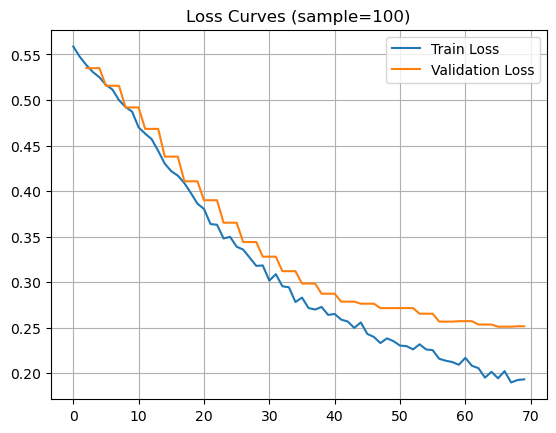

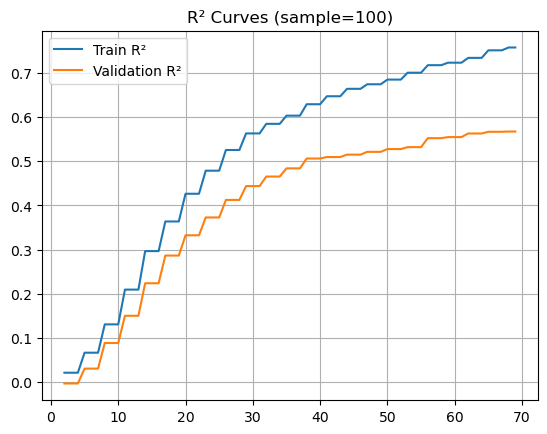

Loaded cached results for sample=500.


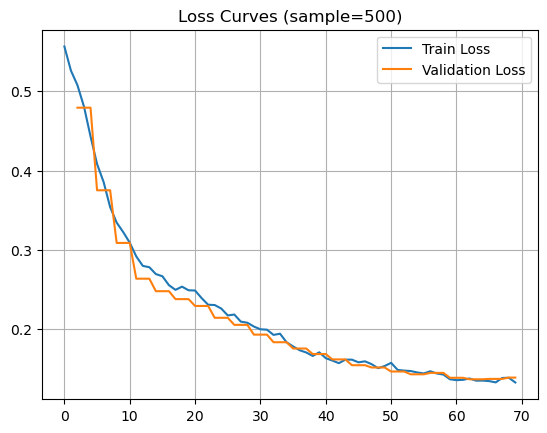

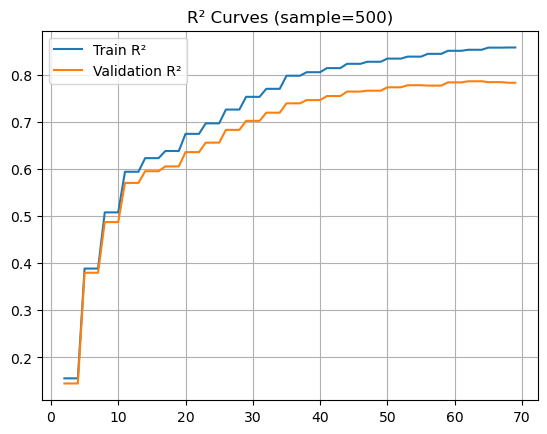

Loaded cached results for sample=1000.


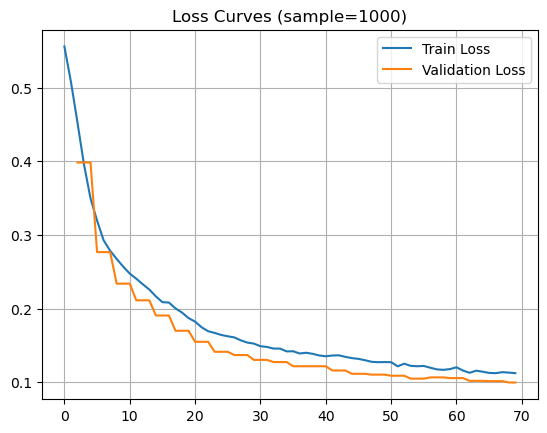

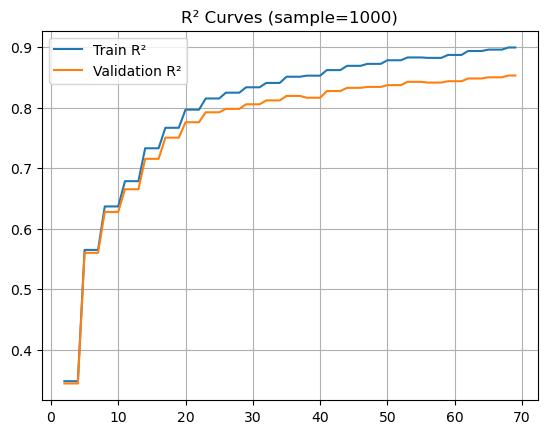

In [83]:
# check if R^2 validation scales with number of examples as my model learns more
# if it does scale, I can continue and make my final @test_and_train function

for sample in [100, 500, 1000]:

    cache_path = f"cached_data/gnn_kfold_sample_{sample}.pkl"

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            results = pickle.load(f)
        print(f"Loaded cached results for sample={sample}.")
    else:
        results = KFoldCrossValidation(
            model_class=GNN,
            graph_dataset=graph_dataset[:sample],
            k=3,
            batch_size=100,
            epochs=70,
            hidden_dim=100,
            dropout=0.25,
            lr=9e-4,
            loss_type="smoothl1",
            beta=0.6,
            device="mps",
            show_progress=False,
            verbose=False, # your eyes will bleed
            make_plots=False,  # disable the inside
            val_every=3,
            train_eval_every=3
        ) # R^2 val does scale with number of samples

        with open(cache_path, "wb") as f:
            pickle.dump(results, f)

        print(f"Saved cached results for sample={sample}.")

    # loss curves and r2 curves
    plt.figure()
    plt.plot(results["avg_train_losses"], label="Train Loss")
    plt.plot(results["avg_val_losses"], label="Validation Loss")
    plt.legend()
    plt.title(f"Loss Curves (sample={sample})")
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(results["avg_train_r2s"], label="Train R²")
    plt.plot(results["avg_val_r2s"], label="Validation R²")
    plt.legend()
    plt.title(f"R² Curves (sample={sample})")
    plt.grid(True)
    plt.show()

Loaded cached results for sample=100.


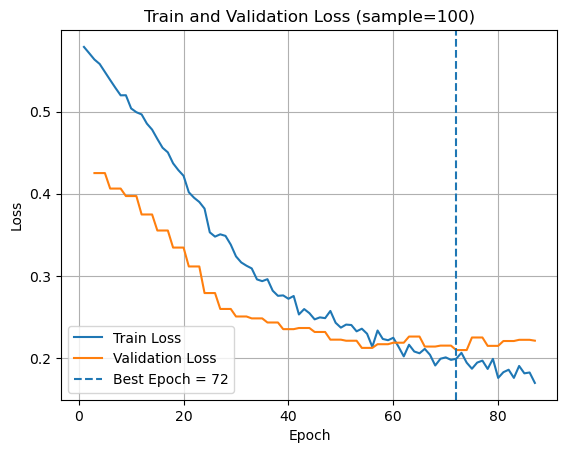

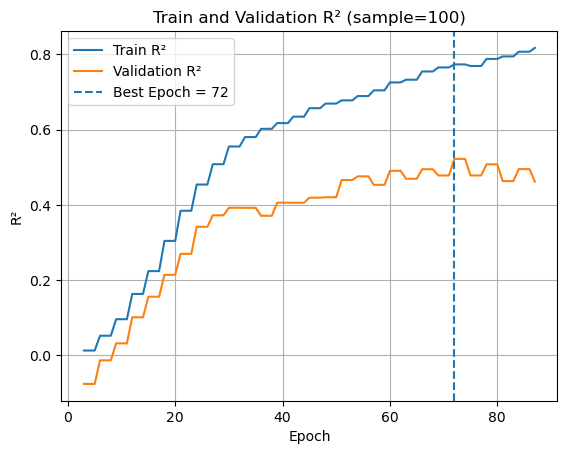

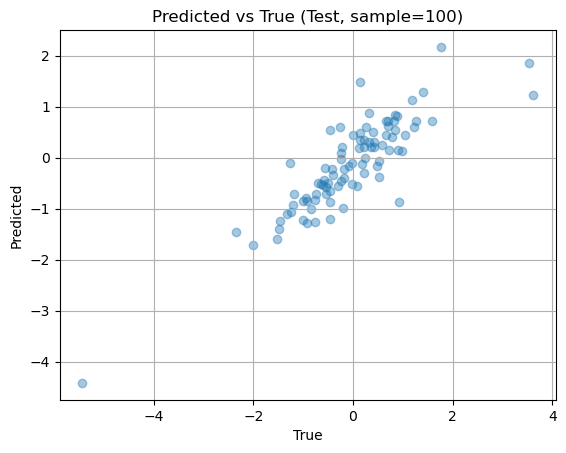

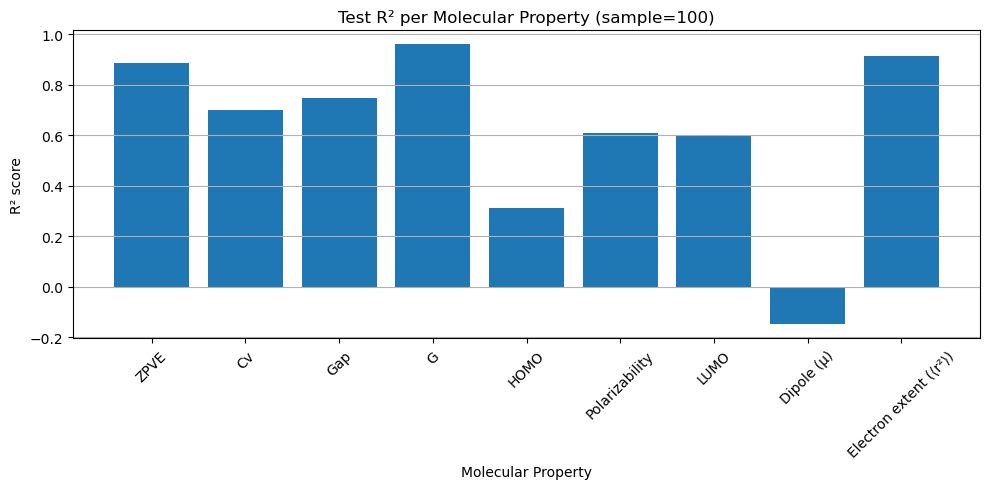

best_epoch: 72
train_r2: 0.7732
val_r2: 0.5221
test_r2: 0.6194

Loaded cached results for sample=500.


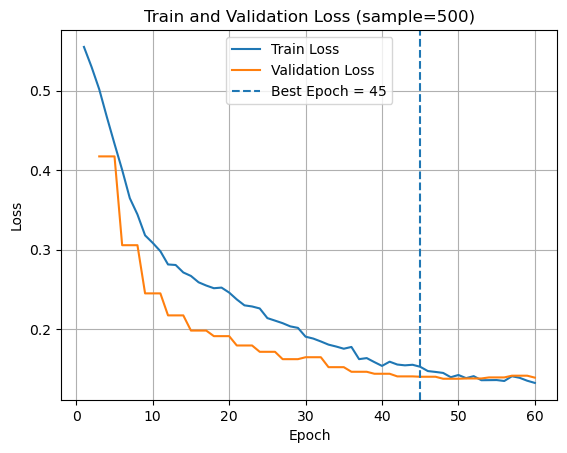

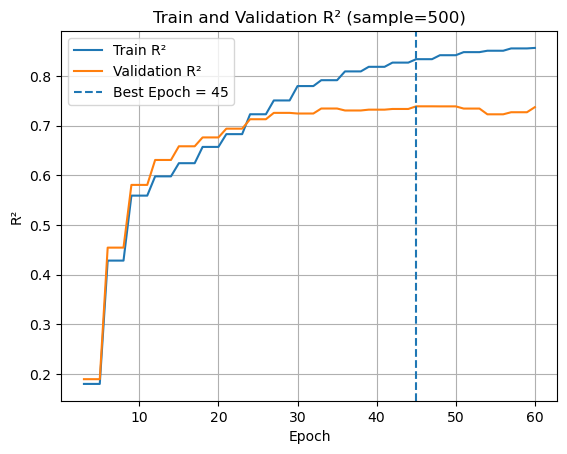

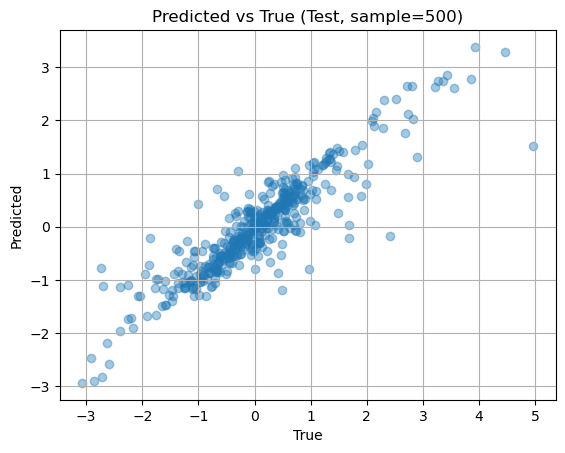

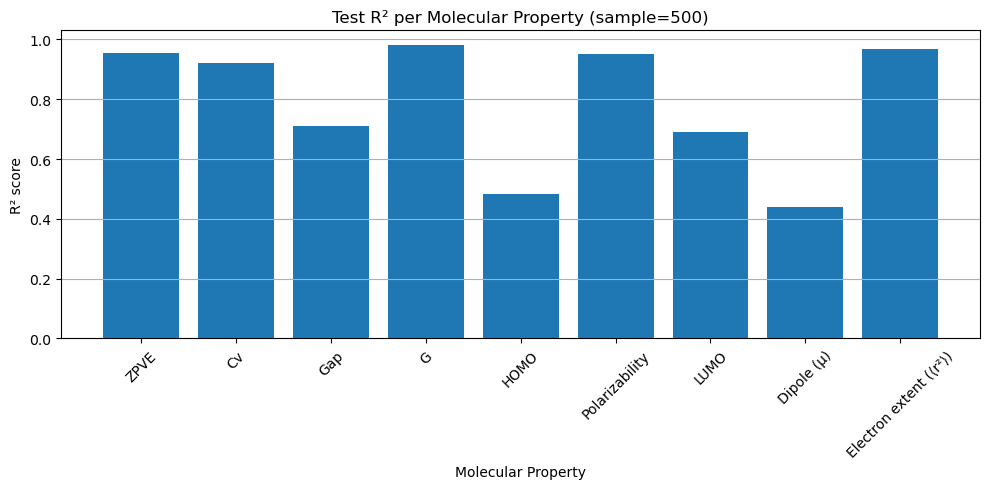

best_epoch: 45
train_r2: 0.8341
val_r2: 0.7392
test_r2: 0.7888

Loaded cached results for sample=1000.


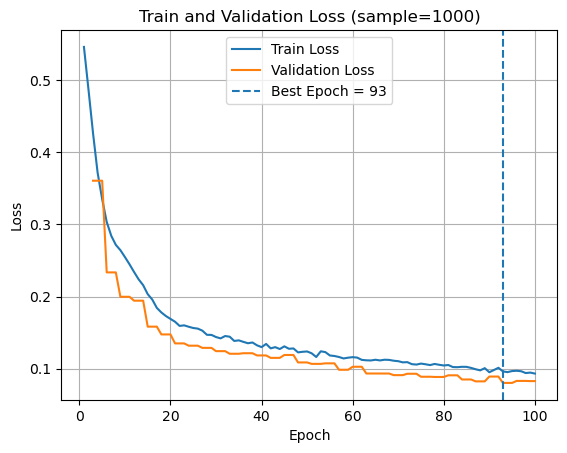

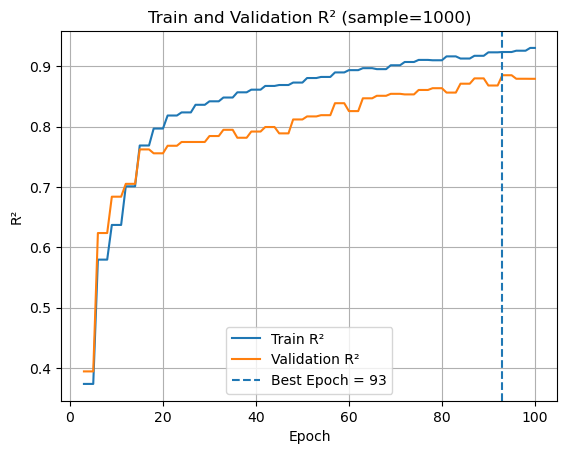

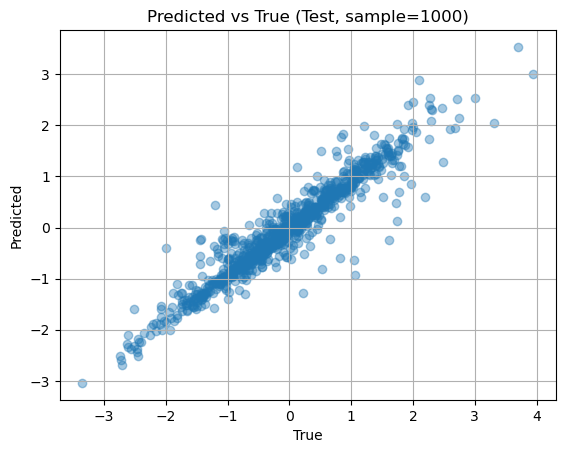

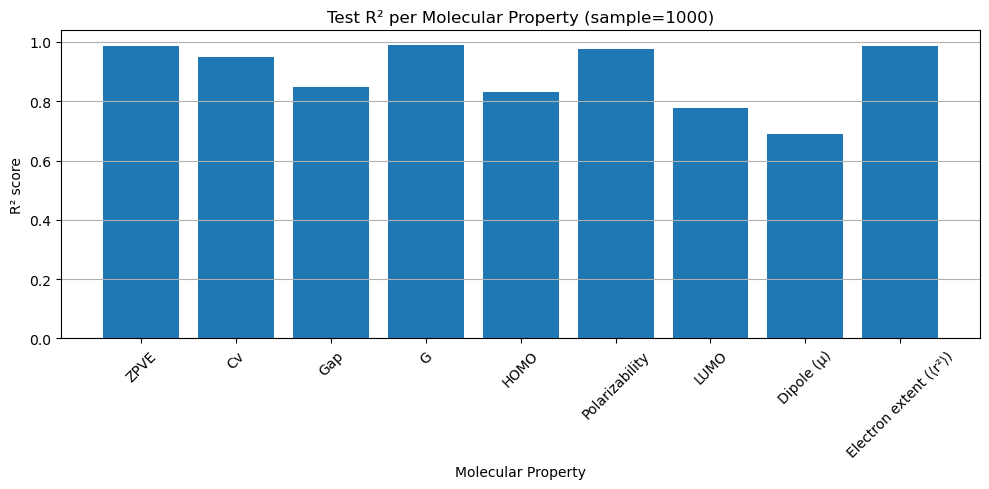

best_epoch: 93
train_r2: 0.9239
val_r2: 0.8854
test_r2: 0.8924



In [84]:
# testing if my final @train_and_test function works well
# using hyperparameters approximated above

for sample in [100, 500, 1000]:

    cache_path = f"cached_data/gnn_trainvaltest_{sample}.pkl"

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            results = pickle.load(f)
        print(f"Loaded cached results for sample={sample}.")
    else:
        results = train_validate_test(
            model_class=GNN,
            graph_dataset=graph_dataset[:sample],
            test_size=0.1,
            val_size=0.1,
            batch_size=100,
            epochs=100,
            hidden_dim=100,
            dropout=0.25,
            lr=9e-4,
            loss_type="smoothl1",
            beta=0.6,
            device="mps",
            random_state=67,
            show_progress=False,
            verbose=False,
            make_plots=False,   # disable internal plotting
            val_every=3,        # validate every 3 epochs
            train_eval_every=3, # also evaluate train R² every 3 epochs
            early_stopping_patience_epochs=15  # stop if val R² does not improve for ~15 epochs
        )

        with open(cache_path, "wb") as f:
            pickle.dump(results, f)

        print(f"Saved cached results for sample={sample}.")

    epochs_ran = len(results["train_losses"])

    # 1. train and validation loss
    plt.figure()
    plt.plot(range(1, epochs_ran + 1), results["train_losses"], label="Train Loss")
    plt.plot(range(1, epochs_ran + 1), results["val_losses"], label="Validation Loss")
    plt.axvline(results["best_epoch"], linestyle="--", label=f"Best Epoch = {results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train and Validation Loss (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 2. train and validation R²
    plt.figure()
    plt.plot(range(1, epochs_ran + 1), results["train_r2s"], label="Train R²")
    plt.plot(range(1, epochs_ran + 1), results["val_r2s"], label="Validation R²")
    plt.axvline(results["best_epoch"], linestyle="--", label=f"Best Epoch = {results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("R²")
    plt.title(f"Train and Validation R² (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # 3. predicted vs true plot aka parity plot
    plt.figure()
    plt.scatter(
        results["test_targets"].flatten().numpy(),
        results["test_preds"].flatten().numpy(),
        alpha=0.4
    )
    plt.xlabel("True")
    plt.ylabel("Predicted")
    plt.title(f"Predicted vs True (Test, sample={sample})")
    plt.grid(True)
    plt.show()

    # 4. per r2 property plot
    clean_property_names = [
        "ZPVE",
        "Cv",
        "Gap",
        "G",
        "HOMO",
        "Polarizability",
        "LUMO",
        "Dipole (μ)",
        "Electron extent (⟨r²⟩)"
    ]

    plt.figure(figsize=(10, 5))
    plt.bar(clean_property_names, results["test_r2_per_output"].cpu().numpy())
    plt.xlabel("Molecular Property")
    plt.ylabel("R² score")
    plt.title(f"Test R² per Molecular Property (sample={sample})")
    plt.xticks(rotation=45)
    plt.grid(True, axis="y")
    plt.tight_layout()
    plt.show()

    print(f"best_epoch: {results['best_epoch']}")
    print(f"train_r2: {results['train_r2']:.4f}")
    print(f"val_r2: {results['val_r2']:.4f}")
    print(f"test_r2: {results['test_r2']:.4f}")
    print()

The model gets more accurate and scales better as we increase samples, so we can continue to the next part which is the transformer.

### (3) Transformer Creation

The first final transformer will use GNN derived information while the second other transformer will not and then compare. 

Once we run the GNN model, we will need to then run the model to get the parameters from molecules we encounter in the USPTO dataset. The predictions will be then used as features to help the transformer perform the prediction for the reaction type being performed. Make these predictions with the GNN model and append them to the reaction_types_df as a list of the list of 9 properties. 

For example say 2 reactants and 1 product will add onto reaction_type_df two columns: reactant_preds and product_preds. The first will have two lists for the two molecules in the reactants, each list having the 9 features. The second will just have one list/molecule again with the 9 properties. 

Before we do that, we have to make sure the dataset has enough of each of the 10 type of reactions.

In [85]:
print(reaction_types_df["category"].value_counts().sort_index())
print(reaction_types_df["category"].value_counts().sum())

category
1      8635
2     10731
3       871
4       606
5       533
6      7556
7      4193
8       732
9      1233
10       26
Name: count, dtype: int64
35116


Class 10 only has 26 examples which is poor even if we reweight everything and it will include alot of noise. Then, because of the imbalance of types of each reaction, we will need use class weights or weighted sampling. Both may be overkill, but we will see. 

In [86]:
reaction_types_df = reaction_types_df[reaction_types_df["category"] != 10].copy()

In [87]:
class USPTOStructurePredictor:
    def __init__(self, model, featurizer, device="cpu", random_seed=67, unnormalize=False):
        self.model = model
        self.featurizer = featurizer
        self.device = device
        self.random_seed = random_seed
        self.unnormalize = unnormalize  
        # control whether to undo normalization
        # do not unnormalize because these will be features in the transformer


    def smiles_to_graph_uspto(self, smiles):
        """
        NOTE: This is a new smiles to graph function 
        meant to be used for smiles in the USPTO dataset to obtain their features. 
        """
        mol = Chem.MolFromSmiles(smiles)
        if mol is None: return None

        # NOTE: Original data for GNN does not have H's
        # This is just to get rough angles and length of bonds as features
        # To use the GNN, then we will remove the H's and proceed
        mol = Chem.AddHs(mol) 
        params = AllChem.ETKDGv3()
        params.randomSeed = self.random_seed

        # attempt no.1 of getting coords (least accurate, always will return something)
        if AllChem.EmbedMolecule(mol, params) != 0: return None 

        if AllChem.MMFFHasAllMoleculeParams(mol):
            try: AllChem.MMFFOptimizeMolecule(mol)
            except: pass # attempt no. 2 (most accurate for small organic molecules)
        elif AllChem.UFFHasAllMoleculeParams(mol):
            try: AllChem.UFFOptimizeMolecule(mol)
            except: pass # attempt no. 3 (less accurate than MMFF but more accurate than ETKDGv3)

        conf = mol.GetConformer()
        coords = [
            [conf.GetAtomPosition(i).x,
             conf.GetAtomPosition(i).y,
             conf.GetAtomPosition(i).z]
            for i in range(mol.GetNumAtoms())
        ]
        
        # get heavy atom indices BEFORE removing H's (important for correct indexing)
        # did not use Chem.RemoveAllHs(mol) else alignment with variable coords
        heavy_idx = [i for i, atom in enumerate(mol.GetAtoms()) if atom.GetAtomicNum() != 1]
        coords = [coords[i] for i in heavy_idx]

        # dummy target just to satisfy graph builder
        y_dummy = [0.0] * len(self.featurizer.target_cols)

        return self.featurizer.smiles_to_graph_alchemy(
            smiles,
            coords,
            y_dummy
        )

    @torch.no_grad()
    def predict_smiles(self, smiles):
        """
        Predict the molecular property vector for one single molecule SMILES.
        """
        self.model.eval()

        data = self.smiles_to_graph_uspto(smiles)
        if data is None: return None

        # single graph -> manually create batch vector
        data.batch = torch.zeros(data.num_nodes, dtype=torch.long)

        data = data.to(self.device)

        pred = self.model(
            data.x,
            data.edge_index,
            data.edge_attr,
            data.batch,
            data.graph_feat
        )
        pred = pred.reshape(1, -1).cpu()

        # DO NOT unnormalize by default — we want normalized features for downstream transformer
        if self.unnormalize:
            pred = self.featurizer.unnormalize_y(pred)

        return pred.flatten().tolist()

    def get_structure_preds(self, smiles_string):
        """
        Input
        =====
            smiles_string : string like "A.B.C" or "A" 
        Output
        ======
            list of predictions (one per molecule)
            where each prediction is a list of values or None
        """
        if pd.isna(smiles_string): return []

        smiles_list = [s.strip() for s in smiles_string.split(".") if s.strip()]
        return [self.predict_smiles(smi) for smi in smiles_list]


    def get_reactant_structure_preds_from_row(self, row):
        return self.get_structure_preds(row["reactant"])


    def get_product_structure_preds_from_row(self, row):
        return self.get_structure_preds(row["product"])


    def add_structure_preds_to_df(self, df, reactant_col="reactant", product_col="product"):
        df = df.copy()

        df["reactant_preds"] = [
            self.get_structure_preds(x)
            for x in tqdm(df[reactant_col], total=len(df))
        ]

        df["product_preds"] = [
            self.get_structure_preds(x)
            for x in tqdm(df[product_col], total=len(df))
        ]

        return df

In [88]:
def stratified_sample_df(df, n, random_state=67):
    df_sample, _ = train_test_split(
        df,
        train_size=n,
        stratify=df["category"],
        random_state=random_state,
        shuffle=True,
    )
    return df_sample.reset_index(drop=True)

cache_path = "cached_data/transformer_subset_999_with_gnn.pkl"

if os.path.exists(cache_path):
    with open(cache_path, "rb") as f:
        subset = pickle.load(f)
    print("Loaded cached subset (with GNN predictions).")

else:
    # build predictor (cheap)
    structure_predictor = USPTOStructurePredictor(
        model=results["model"],
        featurizer=featurizer,
        device=device,
        unnormalize=False
    )

    # build subset (expensive)
    subset = stratified_sample_df(reaction_types_df, n=999, random_state=67)
    subset = structure_predictor.add_structure_preds_to_df(subset)

    with open(cache_path, "wb") as f:
        pickle.dump(subset, f)

    print("Created and cached subset.")

Loaded cached subset (with GNN predictions).


We can now get started with making the transformer herself. We will only have one transfomer model code with some boolean include_gnn_vec that will include our carefuly curated GNN data.

In [89]:
# special tokens that will be used in transformer
pad_token = "[PAD]"   # pad things out
unk_token = "[UNK]"   # unknown

react_mol_token = "[RMOL]"  # beginning of reactant molecule block
prod_mol_token = "[PMOL]"   # beginning of product molecule block
react_gnn_token = "[RGNN]"  # token to be replaced by the reactant gnn vector
prod_gnn_token = "[PGNN]"   # token to be replaced by the product gnn vector
sep_token = "[SEP]"         # seperator between the reactant side and the product side


# group smiles as certain tokens
def tokenize_smiles(smi):
    """
    Tokenizes SMILES while preserving:
        1. Bracketed groups like [NH4+], [O-]
        2. Multicharacter atoms (namely in our study, just Cl)
        3. Reaction Arrow (>>)
        4. Ring closures (%10)
        5. Everything else is single-character (C, H, O, F, ...)
    """
    tokens = []
    i = 0
    n = len(smi)

    while i < n:  # have not used a while loop in years omg
        # this block preserves groups like [NH4+]
        if smi[i] == "[":
            j = i + 1
            while j < n and smi[j] != "]":
                j += 1
            if j < n:
                tokens.append(smi[i:j + 1])
                i = j + 1
            else:
                tokens.append(smi[i])
                i += 1

        # whenever you see a reaction arrow
        elif i + 1 < n and smi[i:i + 2] == ">>":
            tokens.append(">>")
            i += 2

        # whenever you close a ring (%10)
        elif i + 2 < n and smi[i] == "%" and smi[i + 1:i + 3].isdigit():
            tokens.append(smi[i:i + 3])
            i += 3

        # whenever you see chlorine
        elif i + 1 < n and smi[i:i + 2] in ["Cl"]:
            tokens.append(smi[i:i + 2])
            i += 2

        # everything else just single char
        else:
            tokens.append(smi[i])
            i += 1

    return tokens


# helper functions to clean the gnn prediction vectors just in case
# make sure the gnn vec always is always length gnn_dim
def clean_pred_vec(pred, dim=9):
    if pred is None:
        return [0.0] * dim

    if isinstance(pred, (list, tuple, np.ndarray)) and len(pred) == dim:
        out = []
        for x in pred:
            try:
                val = float(x)
                if np.isnan(val):
                    val = 0.0
            except Exception:
                val = 0.0
            out.append(val)
        return out

    return [0.0] * dim  # if all goes bad at least, or if it's not a gnn vec


# make sure the list of gnn vecs is always a list and not None
def ensure_prediction_list(preds):
    if preds is None:
        return []
    if isinstance(preds, list):
        return preds
    if isinstance(preds, tuple):
        return list(preds)
    return []


# build a mixed token sequence for one reaction
def build_reaction_tokens(
    reactant_smiles,
    product_smiles,
    reactant_preds=None,
    product_preds=None,
    include_gnn_vec=False,
    gnn_dim=9,
):
    """
    Output
    ======
    include_gnn_vec = False
        uses the smiles strings only
    include_gnn_vec = True
        uses the smiles strings and gnn vec

    Examples
    ========
    SMILES-only:
        [RMOL] A [RMOL] B [SEP] [PMOL] C
    GNN mode:
        [RMOL] [RGNN] A [RMOL] [RGNN] B [SEP] [PMOL] [PGNN] C
    """
    reactant_parts = [s.strip() for s in reactant_smiles.split(".") if s.strip()]
    product_parts = [s.strip() for s in product_smiles.split(".") if s.strip()]

    if include_gnn_vec:
        reactant_preds = ensure_prediction_list(reactant_preds)
        product_preds = ensure_prediction_list(product_preds)

    tokens = []
    gnn_mask = []
    gnn_values = []

    # reactants
    for i, smi in enumerate(reactant_parts):
        tokens.append(react_mol_token)
        gnn_mask.append(0)
        gnn_values.append([0.0] * gnn_dim)

        if include_gnn_vec:
            mol_pred = clean_pred_vec(
                reactant_preds[i] if i < len(reactant_preds) else None,
                dim=gnn_dim,
            )
            tokens.append(react_gnn_token)
            gnn_mask.append(1)  # is a gnn vec
            gnn_values.append(mol_pred)

        for tok in tokenize_smiles(smi):
            tokens.append(tok)
            gnn_mask.append(0)  # is not a gnn vec
            gnn_values.append([0.0] * gnn_dim)

    # rxn arrow seperator
    tokens.append(sep_token)
    gnn_mask.append(0)
    gnn_values.append([0.0] * gnn_dim)

    # products
    for i, smi in enumerate(product_parts):
        tokens.append(prod_mol_token)
        gnn_mask.append(0)  # is not a gnn vec
        gnn_values.append([0.0] * gnn_dim)

        if include_gnn_vec:
            mol_pred = clean_pred_vec(
                product_preds[i] if i < len(product_preds) else None,
                dim=gnn_dim,
            )
            tokens.append(prod_gnn_token)
            gnn_mask.append(1)  # is a gnn vec
            gnn_values.append(mol_pred)

        for tok in tokenize_smiles(smi):
            tokens.append(tok)
            gnn_mask.append(0)  # is not a gnn vec
            gnn_values.append([0.0] * gnn_dim)

    return tokens, gnn_mask, gnn_values


# master class to build vocab and corrsponding inetger id's
class ReactionTokenizer:
    def __init__(self):
        # token2index is the main vocab dict mapping token to int id
        self.token2idx = {
            pad_token: 0,
            unk_token: 1,
            react_mol_token: 2,
            prod_mol_token: 3,
            react_gnn_token: 4,
            prod_gnn_token: 5,
            sep_token: 6,
        }

        # reverse mapping: int id -> token
        self.idx2token = {idx: tok for tok, idx in self.token2idx.items()}

    def add_token(self, token):
        if token not in self.token2idx:
            idx = len(self.token2idx)
            self.token2idx[token] = idx
            self.idx2token[idx] = token

    def build_vocab(self, df):
        # add all smile tokens from react and prod
        for _, row in df.iterrows():
            reactant_parts = [s.strip() for s in row["reactant"].split(".") if s.strip()]
            product_parts = [s.strip() for s in row["product"].split(".") if s.strip()]

            for smi in reactant_parts:
                for tok in tokenize_smiles(smi):
                    self.add_token(tok)

            for smi in product_parts:
                for tok in tokenize_smiles(smi):
                    self.add_token(tok)

    def encode_tokens(self, tokens):
        # return an array integers for the token
        # if not return the int for the unknown (.get(...))
        unk_idx = self.token2idx[unk_token]
        return [self.token2idx.get(tok, unk_idx) for tok in tokens]

    def decode_ids(self, ids):
        # return an array of the ids from the idx
        # if not return the idx for the unknown (.get(...))
        return [self.idx2token.get(i, unk_token) for i in ids]

    @property  # decorator for a class variable
    # example: tokenizer.vocab_size
    def vocab_size(self):
        return len(self.token2idx)


# convert df of reactions I made into something pytorch can train on
class ReactionDataset(TorchDataset):
    def __init__(self, df, tokenizer, include_gnn_vec=False, gnn_dim=9):
        self.df = df.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.include_gnn_vec = include_gnn_vec
        self.gnn_dim = gnn_dim
        self.labels = self.df["category"].tolist() if "category" in self.df.columns else None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        tokens, gnn_mask, gnn_values = build_reaction_tokens(
            reactant_smiles=row["reactant"],
            product_smiles=row["product"],
            reactant_preds=row.get("reactant_preds", None),
            product_preds=row.get("product_preds", None),
            include_gnn_vec=self.include_gnn_vec,
            gnn_dim=self.gnn_dim,
        )

        input_ids = torch.tensor(
            self.tokenizer.encode_tokens(tokens),
            dtype=torch.long,
        )

        # 1 means real token, 0 means padding
        attention_mask = torch.ones(len(tokens), dtype=torch.long)

        # marks which positions correspond to [RGNN] or [PGNN]
        gnn_mask = torch.tensor(gnn_mask, dtype=torch.bool)

        # per-token 9-dim GNN
        gnn_values = torch.tensor(gnn_values, dtype=torch.float)

        item = {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "gnn_mask": gnn_mask,
            "gnn_values": gnn_values,
        }

        # do not -1 here bc already remapped labels in ReactionTransformerClassifier.fit()
        if self.labels is not None:
            label = torch.tensor(int(self.labels[idx]), dtype=torch.long)
            item["label"] = label
        # ordered like this so that when self.labels = None doesn't error

        return item


# make sure the bacthes are all the same length
def reaction_collate_fn(batch):
    """
    Pad variable-length reaction sequences into one batch.
    Make sure that they are all the same length for batching.
    """
    input_ids = [item["input_ids"] for item in batch]
    attention_mask = [item["attention_mask"] for item in batch]
    gnn_mask = [item["gnn_mask"] for item in batch]
    gnn_values = [item["gnn_values"] for item in batch]

    input_ids = pad_sequence(input_ids, batch_first=True, padding_value=0)
    attention_mask = pad_sequence(attention_mask, batch_first=True, padding_value=0)
    gnn_mask = pad_sequence(gnn_mask, batch_first=True, padding_value=0)
    gnn_values = pad_sequence(gnn_values, batch_first=True, padding_value=0.0)

    out = {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "gnn_mask": gnn_mask,
        "gnn_values": gnn_values,
    }

    # only include labels if they exist (training vs inference)
    if "label" in batch[0]:
        out["label"] = torch.stack([item["label"] for item in batch])
    # prevents predict crash

    return out


# positional encoder or else OCN = NOC
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=512):
        super().__init__()
        self.dropout = nn.Dropout(dropout)

        # initialize
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(max_len).unsqueeze(1).float()  # [max_len, 1]
        frequency = torch.exp(
            torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
        )

        # even is sine and odd is cosine, then add a dim for batch
        pe[:, 0::2] = torch.sin(position * frequency)
        pe[:, 1::2] = torch.cos(position * frequency)
        pe = pe.unsqueeze(0)  # [1, max_len, d_model]
        self.register_buffer("pe", pe)

    def forward(self, x):  # x is [batch_len, seq_len, d_model]
        x = x + self.pe[:, :x.size(1), :]  # positional encoding to embeddings
        return self.dropout(x)


# finally, for the actual transformer itself
class ReactionTransformer(nn.Module):
    def __init__(
        self,
        vocab_size,
        num_classes,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        max_len=512,
        gnn_dim=9,
        include_gnn_vec=False,
    ):
        super().__init__()

        self.include_gnn_vec = include_gnn_vec
        self.token_embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.positional_encoding = PositionalEncoding(d_model, dropout=dropout, max_len=max_len)

        # project gnn vec into same embedding size as token embeds
        self.gnn_projection = nn.Sequential(
            nn.Linear(gnn_dim, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model),
        )

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True,
        )

        self.encoder = nn.TransformerEncoder(
            encoder_layer,
            num_layers=num_layers,
            enable_nested_tensor=False,  # experimental does not always work
        )

        # then finally a classifier for one of the reaction types
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, num_classes),
        )

    def forward(self, input_ids, attention_mask, gnn_mask=None, gnn_values=None):
        x = self.token_embedding(input_ids)

        # if gnn vec, shove it in
        if self.include_gnn_vec and gnn_mask is not None and gnn_values is not None:
            gnn_emb = self.gnn_projection(gnn_values)
            x = torch.where(gnn_mask.unsqueeze(-1), gnn_emb, x)

        x = self.positional_encoding(x)  # order matters

        # make transformer ignore where attention mask == 0
        # which are fake tokens added for batching
        key_padding_mask = (attention_mask == 0)
        x = self.encoder(x, src_key_padding_mask=key_padding_mask)

        # mean pool only w/ real tokens
        mask = attention_mask.unsqueeze(-1).float()
        pooled = (x * mask).sum(dim=1) / mask.sum(dim=1).clamp_min(1.0)

        logits = self.classifier(pooled)
        return logits


# trainer like GNN but instead of R^2 uses accuracy / F1 (classification task)
class TransformerTrainer:
    def __init__(
        self,
        model,
        optimizer=torch.optim.Adam,
        lr=1e-3,
        device="cpu",
        class_weights=None,
    ):
        super().__init__()

        self.model = model.to(device)
        self.device = device
        self.optimizer = optimizer(self.model.parameters(), lr=lr)

        # reaction category prediction = multiclass classification
        if class_weights is not None:
            class_weights = class_weights.to(device)
        self.loss_function = nn.CrossEntropyLoss(weight=class_weights)

    def train_one_epoch(self, loader):
        self.model.train()
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        for batch in loader:
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            gnn_mask = batch["gnn_mask"].to(self.device)
            gnn_values = batch["gnn_values"].to(self.device)
            labels = batch["label"].to(self.device).long()

            self.optimizer.zero_grad()

            logits = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                gnn_mask=gnn_mask,
                gnn_values=gnn_values,
            )

            loss = self.loss_function(logits, labels)
            loss.backward()
            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_count += labels.size(0)

        avg_loss = total_loss / len(loader)
        avg_acc = total_correct / total_count

        return avg_loss, avg_acc

    @torch.no_grad()
    def evaluate(self, loader):
        self.model.eval()
        total_loss = 0.0
        total_correct = 0
        total_count = 0

        all_preds = []
        all_labels = []

        for batch in loader:
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            gnn_mask = batch["gnn_mask"].to(self.device)
            gnn_values = batch["gnn_values"].to(self.device)
            labels = batch["label"].to(self.device).long()

            logits = self.model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                gnn_mask=gnn_mask,
                gnn_values=gnn_values,
            )

            loss = self.loss_function(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_count += labels.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

        avg_loss = total_loss / len(loader)
        avg_acc = total_correct / total_count

        all_preds = torch.cat(all_preds, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        avg_f1 = f1_score(all_labels.numpy(), all_preds.numpy(), average="macro")

        return avg_loss, avg_acc, avg_f1, all_preds, all_labels

    def fit(self, train_loader, val_loader, epochs=20, show_progress=True):
        train_losses = []
        val_losses = []
        train_accs = []
        val_accs = []
        val_f1s = []

        best_val_loss = float("inf")
        best_train_loss = None
        best_train_acc = None
        best_val_acc = None
        best_val_f1 = None

        for epoch in range(1, epochs + 1):
            train_loss, train_acc = self.train_one_epoch(train_loader)
            val_loss, val_acc, val_f1, _, _ = self.evaluate(val_loader)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            train_accs.append(train_acc)
            val_accs.append(val_acc)
            val_f1s.append(val_f1)

            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_train_loss = train_loss
                best_train_acc = train_acc
                best_val_acc = val_acc
                best_val_f1 = val_f1

            if show_progress:
                print(
                    f"Epoch {epoch}: "
                    f"train_loss={train_loss:.4f}, "
                    f"train_acc={train_acc:.4f}, "
                    f"val_loss={val_loss:.4f}, "
                    f"val_acc={val_acc:.4f}, "
                    f"val_f1={val_f1:.4f}"
                )

        return {
            "best_train_loss": best_train_loss,
            "best_val_loss": best_val_loss,
            "best_train_acc": best_train_acc,
            "best_val_acc": best_val_acc,
            "best_val_f1": best_val_f1,
            "train_losses": train_losses,
            "val_losses": val_losses,
            "train_accs": train_accs,
            "val_accs": val_accs,
            "val_f1s": val_f1s,
        }

In [90]:
# This is structured just like the GNN functions just with certain parts
# swapped to perform the correct task

# train one transformer on one train/validation split
def train_single_split_transformer(
    model_class,
    train_df,
    val_df,
    tokenizer,
    include_gnn_vec=False,
    batch_size=32,
    epochs=20,
    optimizer=torch.optim.Adam,
    lr=1e-3,
    device="cpu",
    show_progress=False,
    val_every=1,
    train_eval_every=1,
    model_kwargs=None,
    use_class_weights=False,
    use_weighted_sampling=True,
    gnn_dim=9,
):
    """
    Train one transformer on one split.
    Returns metrics + validation predictions (for confusion matrix).
    """

    if model_kwargs is None:
        model_kwargs = {}

    # datasets
    train_dataset = ReactionDataset(
        train_df,
        tokenizer,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim
    )
    val_dataset = ReactionDataset(
        val_df,
        tokenizer,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim
    )

    # weighted sampling is a stronger way to handle class imbalance
    if use_weighted_sampling:
        class_counts = train_df["category"].value_counts().sort_index()
        class_weights_for_sampling = 1.0 / class_counts
        sample_weights = train_df["category"].map(class_weights_for_sampling).values

        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights, dtype=torch.float),
            num_samples=len(sample_weights),
            replacement=True
        )

        train_loader = TorchDataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            collate_fn=reaction_collate_fn
        )
    else:
        train_loader = TorchDataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=reaction_collate_fn
        )

    val_loader = TorchDataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=reaction_collate_fn
    )

    # model
    model = model_class(
        vocab_size=tokenizer.vocab_size,
        num_classes=len(sorted(train_df["category"].unique())),
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim,
        **model_kwargs
    )

    # optional class weights
    class_weights = None
    if use_class_weights:
        classes = np.sort(train_df["category"].unique())
        weights = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=train_df["category"].values
        )
        class_weights = torch.tensor(weights, dtype=torch.float)

    trainer = TransformerTrainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        device=device,
        class_weights=class_weights
    )

    model = trainer.model.to(device)

    # tracking
    train_losses, val_losses = [], []
    train_accs, val_accs = [], []
    train_f1s, val_f1s = [], []

    best_val_loss = float("inf")
    best_train_loss = None
    best_train_acc = None
    best_train_f1 = None
    best_val_acc = None
    best_val_f1 = None
    best_state_dict = None

    # for confusion matrix
    best_val_preds = None
    best_val_labels = None

    # initialize "carry forward" values
    last_train_acc = 0.0
    last_train_f1 = 0.0
    last_val_loss = float("inf")
    last_val_acc = 0.0
    last_val_f1 = 0.0

    for epoch in range(1, epochs + 1):

        # always train
        train_loss, _ = trainer.train_one_epoch(train_loader)

        # evaluate train periodically
        if epoch % train_eval_every == 0:
            _, train_acc_eval, train_f1_eval, _, _ = trainer.evaluate(train_loader)
            last_train_acc = train_acc_eval
            last_train_f1 = train_f1_eval

        # evaluate validation periodically
        if epoch % val_every == 0:
            val_loss, val_acc, val_f1, val_preds, val_labels = trainer.evaluate(val_loader)

            last_val_loss = val_loss
            last_val_acc = val_acc
            last_val_f1 = val_f1

            # track best model
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_train_loss = train_loss
                best_train_acc = last_train_acc
                best_train_f1 = last_train_f1
                best_val_acc = val_acc
                best_val_f1 = val_f1
                best_state_dict = copy.deepcopy(model.state_dict())

                # store preds for confusion matrix
                best_val_preds = val_preds
                best_val_labels = val_labels

        # append (carry forward values)
        train_losses.append(train_loss)
        val_losses.append(last_val_loss)
        train_accs.append(last_train_acc)
        val_accs.append(last_val_acc)
        train_f1s.append(last_train_f1)
        val_f1s.append(last_val_f1)

        if show_progress:
            print(
                f"Epoch {epoch}: "
                f"train_loss={train_loss:.4f}, "
                f"train_acc={last_train_acc:.4f}, "
                f"train_f1={last_train_f1:.4f}, "
                f"val_loss={last_val_loss:.4f}, "
                f"val_acc={last_val_acc:.4f}, "
                f"val_f1={last_val_f1:.4f}"
            )

    # safety fallback
    if best_state_dict is None:
        best_state_dict = copy.deepcopy(model.state_dict())
        _, _, _, best_val_preds, best_val_labels = trainer.evaluate(val_loader)

    # reload best model
    model.load_state_dict(best_state_dict)
    model.eval()

    return {
        "model": model,

        "best_train_loss": best_train_loss,
        "best_val_loss": best_val_loss,
        "best_train_acc": best_train_acc,
        "best_train_f1": best_train_f1,
        "best_val_acc": best_val_acc,
        "best_val_f1": best_val_f1,

        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "train_f1s": train_f1s,
        "val_f1s": val_f1s,

        # REQUIRED for confusion matrix
        "val_preds": best_val_preds,
        "val_labels": best_val_labels,
    }


# replace regression R^2 with classification accuracy / macro-F1
# function used to see if the transformer scales well and does not explode
def KFoldCrossValidationTransformer(
    model_class,
    df,
    tokenizer,
    include_gnn_vec=False,
    k=3,
    batch_size=32,
    epochs=20,
    optimizer=torch.optim.Adam,
    lr=1e-3,
    device="cpu",
    early_break=False,
    show_progress=False,
    make_plots=True,
    verbose=True,
    random_state=67,
    val_every=1,
    train_eval_every=1,
    model_kwargs=None,
    use_class_weights=False,
    use_weighted_sampling=True,
    gnn_dim=9,
):
    """
    Run either:
    - k=1: a single train/validation split
    - k>1: k-fold cross validation

    Returns only metrics for evaluation / hyperparameter search.
    Does NOT return a model. (No need.)
    """
    if model_kwargs is None:
        model_kwargs = {}

    df = df.reset_index(drop=True)

    if k == 1:
        train_df, val_df = train_test_split(
            df,
            test_size=0.2,
            random_state=random_state,
            shuffle=True,
            stratify=df["category"]
        )
        splits = [(train_df.index.tolist(), val_df.index.tolist())]
    else:
        kf = StratifiedKFold(n_splits=k, shuffle=True, random_state=random_state)
        splits = kf.split(df, df["category"])

    # contain results for each fold to compute average and std dev
    train_loss_list = []
    val_loss_list = []
    train_acc_list = []
    val_acc_list = []
    train_f1_list = []
    val_f1_list = []

    all_train_losses = []
    all_val_losses = []
    all_train_accs = []
    all_val_accs = []
    all_train_f1s = []
    all_val_f1s = []

    all_val_preds = []
    all_val_labels = []  # for confusion matrix across folds

    for fold, (train_idx, val_idx) in enumerate(splits):
        train_df = df.iloc[train_idx].reset_index(drop=True)
        val_df = df.iloc[val_idx].reset_index(drop=True)

        fold_results = train_single_split_transformer(
            model_class=model_class,
            train_df=train_df,
            val_df=val_df,
            tokenizer=tokenizer,
            include_gnn_vec=include_gnn_vec,
            batch_size=batch_size,
            epochs=epochs,
            optimizer=optimizer,
            lr=lr,
            device=device,
            show_progress=show_progress,
            val_every=val_every,
            train_eval_every=train_eval_every,
            model_kwargs=model_kwargs,
            use_class_weights=use_class_weights,
            use_weighted_sampling=use_weighted_sampling,
            gnn_dim=gnn_dim,
        )

        train_loss_best = fold_results["best_train_loss"]
        val_loss_best = fold_results["best_val_loss"]
        train_acc_best = fold_results["best_train_acc"]
        train_f1_best = fold_results["best_train_f1"]
        val_acc_best = fold_results["best_val_acc"]
        val_f1_best = fold_results["best_val_f1"]

        train_loss_list.append(train_loss_best)
        val_loss_list.append(val_loss_best)
        train_acc_list.append(train_acc_best)
        val_acc_list.append(val_acc_best)
        train_f1_list.append(train_f1_best)
        val_f1_list.append(val_f1_best)

        all_train_losses.append(fold_results["train_losses"])
        all_val_losses.append(fold_results["val_losses"])
        all_train_accs.append(fold_results["train_accs"])
        all_val_accs.append(fold_results["val_accs"])
        all_train_f1s.append(fold_results["train_f1s"])
        all_val_f1s.append(fold_results["val_f1s"])

        # store validation predictions / labels for one big confusion matrix across folds
        all_val_preds.append(fold_results["val_preds"])
        all_val_labels.append(fold_results["val_labels"])

        if verbose:
            print(f"\nFold {fold+1}")
            print(f"Best train loss: {train_loss_best:.4f}")
            print(f"Best val loss: {val_loss_best:.4f}")
            print(f"Best train acc: {train_acc_best:.4f}")
            print(f"Best train f1: {train_f1_best:.4f}")
            print(f"Best val acc: {val_acc_best:.4f}")
            print(f"Best val f1: {val_f1_best:.4f}")

        if early_break:
            break

    # average curves across folds
    avg_train_losses = np.nanmean(np.array(all_train_losses), axis=0)
    avg_val_losses = np.nanmean(np.array(all_val_losses), axis=0)
    avg_train_accs = np.nanmean(np.array(all_train_accs), axis=0)
    avg_val_accs = np.nanmean(np.array(all_val_accs), axis=0)
    avg_train_f1s = np.nanmean(np.array(all_train_f1s), axis=0)
    avg_val_f1s = np.nanmean(np.array(all_val_f1s), axis=0)

    # combine all fold validation predictions / labels
    all_val_preds = torch.cat(all_val_preds, dim=0)
    all_val_labels = torch.cat(all_val_labels, dim=0)

    if make_plots:
        plt.figure()
        plt.plot(avg_train_losses, label="Average Train Loss")
        plt.plot(avg_val_losses, label="Average Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Training and Validation Loss Curves")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure()
        plt.plot(avg_train_accs, label="Train Accuracy")
        plt.plot(avg_val_accs, label="Validation Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Train vs Validation Accuracy")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure()
        plt.plot(avg_train_f1s, label="Train Macro-F1")
        plt.plot(avg_val_f1s, label="Validation Macro-F1")
        plt.xlabel("Epoch")
        plt.ylabel("Macro-F1")
        plt.title("Train vs Validation Macro-F1")
        plt.legend()
        plt.grid(True)
        plt.show()

        # confusion matrix across all validation folds
        cm = confusion_matrix(all_val_labels.numpy(), all_val_preds.numpy(), normalize="true")
        plt.figure(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues", values_format=".2f")
        plt.title("K-Fold Validation Confusion Matrix (Normalized)")
        plt.grid(False)
        plt.show()

    summary = {
        # hyperparameters I tracked here
        "hyperparameters": {
            "k": k,
            "batch_size": batch_size,
            "epochs": epochs,
            "optimizer": optimizer.__name__ if hasattr(optimizer, "__name__") else str(optimizer),
            "lr": lr,
            "device": device,
            "random_state": random_state,
            "include_gnn_vec": include_gnn_vec,
            "val_every": val_every,
            "train_eval_every": train_eval_every,
            "model_kwargs": model_kwargs,
            "use_class_weights": use_class_weights,
            "use_weighted_sampling": use_weighted_sampling,
            "gnn_dim": gnn_dim,
        },

        # main metrics
        "mean_train_loss": float(np.nanmean(train_loss_list)),
        "std_train_loss": float(np.nanstd(train_loss_list)),
        "mean_val_loss": float(np.nanmean(val_loss_list)),
        "std_val_loss": float(np.nanstd(val_loss_list)),

        "mean_train_acc": float(np.nanmean(train_acc_list)),
        "std_train_acc": float(np.nanstd(train_acc_list)),
        "mean_val_acc": float(np.nanmean(val_acc_list)),
        "std_val_acc": float(np.nanstd(val_acc_list)),

        "mean_train_f1": float(np.nanmean(train_f1_list)),
        "std_train_f1": float(np.nanstd(train_f1_list)),
        "mean_val_f1": float(np.nanmean(val_f1_list)),
        "std_val_f1": float(np.nanstd(val_f1_list)),

        # per-fold metrics
        "train_loss_per_fold": train_loss_list,
        "val_loss_per_fold": val_loss_list,
        "train_acc_per_fold": train_acc_list,
        "val_acc_per_fold": val_acc_list,
        "train_f1_per_fold": train_f1_list,
        "val_f1_per_fold": val_f1_list,

        # average curves
        "avg_train_losses": avg_train_losses,
        "avg_val_losses": avg_val_losses,
        "avg_train_accs": avg_train_accs,
        "avg_val_accs": avg_val_accs,
        "avg_train_f1s": avg_train_f1s,
        "avg_val_f1s": avg_val_f1s,

        # combined validation predictions
        "val_preds": all_val_preds,
        "val_labels": all_val_labels,
    }

    if make_plots:
        print("\nFinal results:")
        print(f"Train loss: {summary['mean_train_loss']:.4f} ± {summary['std_train_loss']:.4f}")
        print(f"Val loss: {summary['mean_val_loss']:.4f} ± {summary['std_val_loss']:.4f}")
        print(f"Train acc: {summary['mean_train_acc']:.4f} ± {summary['std_train_acc']:.4f}")
        print(f"Val acc: {summary['mean_val_acc']:.4f} ± {summary['std_val_acc']:.4f}")
        print(f"Train f1: {summary['mean_train_f1']:.4f} ± {summary['std_train_f1']:.4f}")
        print(f"Val f1: {summary['mean_val_f1']:.4f} ± {summary['std_val_f1']:.4f}")

    return summary


# final function to train/val/test on the whole reaction dataset
def train_validate_test_transformer(
    model_class,
    df,
    tokenizer,
    include_gnn_vec=False,
    test_size=0.1,
    val_size=0.1,
    batch_size=32,
    epochs=20,
    optimizer=torch.optim.Adam,
    lr=1e-3,
    device="cpu",
    random_state=67,
    show_progress=False,
    verbose=True,
    make_plots=True,
    val_every=1,
    train_eval_every=1,
    early_stopping_patience_epochs=15,
    model_kwargs=None,
    use_class_weights=False,
    use_weighted_sampling=True,
    gnn_dim=9,
):
    """
    Used in the final evaluation phase after hyperparameter tuning to train
    a transformer on the full training set and evaluate on the test set.
    1. Split full dataset into train_pool and test
    2. Split train_pool into train and val
    3. Train on train
    4. Save best checkpoint based on val loss
    5. Reload best checkpoint
    6. Evaluate once on train/val/test

    If val_every > 1 or train_eval_every > 1, skipped epochs keep the
    previous evaluation value so plots remain continuous.
    """
    if model_kwargs is None:
        model_kwargs = {}

    df = df.reset_index(drop=True)

    # train pool and test
    train_pool_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=random_state,
        shuffle=True,
        stratify=df["category"]
    )

    # train and val
    adjusted_val_size = val_size / (1 - test_size)

    train_df, val_df = train_test_split(
        train_pool_df,
        test_size=adjusted_val_size,
        random_state=random_state,
        shuffle=True,
        stratify=train_pool_df["category"]
    )

    # build datasets
    train_dataset = ReactionDataset(
        train_df,
        tokenizer,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim
    )
    val_dataset = ReactionDataset(
        val_df,
        tokenizer,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim
    )
    test_dataset = ReactionDataset(
        test_df,
        tokenizer,
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim
    )

    # weighted sampling is a stronger way to handle class imbalance
    if use_weighted_sampling:
        class_counts = train_df["category"].value_counts().sort_index()
        class_weights_for_sampling = 1.0 / class_counts
        sample_weights = train_df["category"].map(class_weights_for_sampling).values

        sampler = WeightedRandomSampler(
            weights=torch.tensor(sample_weights, dtype=torch.float),
            num_samples=len(sample_weights),
            replacement=True
        )

        # build loaders
        train_loader = TorchDataLoader(
            train_dataset,
            batch_size=batch_size,
            sampler=sampler,
            collate_fn=reaction_collate_fn
        )
    else:
        # build loaders
        train_loader = TorchDataLoader(
            train_dataset,
            batch_size=batch_size,
            shuffle=True,
            collate_fn=reaction_collate_fn
        )

    val_loader = TorchDataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=reaction_collate_fn
    )
    test_loader = TorchDataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        collate_fn=reaction_collate_fn
    )

    # build model + trainer
    model = model_class(
        vocab_size=tokenizer.vocab_size,
        num_classes=len(sorted(df["category"].unique())),
        include_gnn_vec=include_gnn_vec,
        gnn_dim=gnn_dim,
        **model_kwargs
    )

    # optional class weights
    class_weights = None
    if use_class_weights:
        classes = np.sort(train_df["category"].unique())
        weights = compute_class_weight(
            class_weight="balanced",
            classes=classes,
            y=train_df["category"].values
        )
        class_weights = torch.tensor(weights, dtype=torch.float)

    trainer = TransformerTrainer(
        model=model,
        optimizer=optimizer,
        lr=lr,
        device=device,
        class_weights=class_weights
    )

    model = trainer.model.to(device)

    # tracking all of this
    train_losses = []
    val_losses = []
    train_accs = []
    val_accs = []
    train_f1s = []
    val_f1s = []

    best_val_loss = float("inf")
    best_epoch = None
    best_state_dict = None

    # keep previous evaluations so skipped epochs still plot nicely
    last_train_acc = np.nan
    last_train_f1 = np.nan
    last_val_loss = np.nan
    last_val_acc = np.nan
    last_val_f1 = np.nan

    # early stopping should depend on how often validation is checked
    patience_checks = max(1, early_stopping_patience_epochs // val_every)
    no_improve_count = 0

    # training loop
    for epoch in range(1, epochs + 1):
        train_loss, _ = trainer.train_one_epoch(train_loader)
        train_losses.append(train_loss)

        # train evaluation only every few epochs
        if epoch % train_eval_every == 0:
            _, last_train_acc, last_train_f1, _, _ = trainer.evaluate(train_loader)
        train_accs.append(last_train_acc)
        train_f1s.append(last_train_f1)

        # validation only every few epochs
        if epoch % val_every == 0:
            last_val_loss, last_val_acc, last_val_f1, _, _ = trainer.evaluate(val_loader)

            if last_val_loss < best_val_loss:
                best_val_loss = last_val_loss
                best_epoch = epoch
                best_state_dict = copy.deepcopy(model.state_dict())
                no_improve_count = 0
            else:
                no_improve_count += 1

        val_losses.append(last_val_loss)
        val_accs.append(last_val_acc)
        val_f1s.append(last_val_f1)

        if show_progress:
            train_acc_str = f"{last_train_acc:.4f}" if not np.isnan(last_train_acc) else "nan"
            train_f1_str = f"{last_train_f1:.4f}" if not np.isnan(last_train_f1) else "nan"
            val_loss_str = f"{last_val_loss:.4f}" if not np.isnan(last_val_loss) else "nan"
            val_acc_str = f"{last_val_acc:.4f}" if not np.isnan(last_val_acc) else "nan"
            val_f1_str = f"{last_val_f1:.4f}" if not np.isnan(last_val_f1) else "nan"

            print(
                f"Epoch {epoch}: "
                f"train_loss={train_loss:.4f}, "
                f"train_acc={train_acc_str}, "
                f"train_f1={train_f1_str}, "
                f"val_loss={val_loss_str}, "
                f"val_acc={val_acc_str}, "
                f"val_f1={val_f1_str}"
            )

        # early stopping based on number of validation checks with no improvement
        if no_improve_count >= patience_checks:
            if verbose:
                print(
                    f"Early stopping at epoch {epoch} "
                    f"(no val loss improvement for ~{early_stopping_patience_epochs} epochs)."
                )
            break

    if best_state_dict is None:
        best_state_dict = copy.deepcopy(model.state_dict())
        best_epoch = epoch

    # reload best checkpoint
    model.load_state_dict(best_state_dict)
    model.eval()

    # helper function for final eval
    @torch.no_grad()
    def detailed_evaluation(loader):
        total_loss = 0.0
        total_correct = 0
        total_count = 0
        all_preds = []
        all_labels = []

        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            gnn_mask = batch["gnn_mask"].to(device)
            gnn_values = batch["gnn_values"].to(device)
            labels = batch["label"].to(device).long()

            logits = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                gnn_mask=gnn_mask,
                gnn_values=gnn_values
            )

            loss = trainer.loss_function(logits, labels)
            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)
            total_correct += (preds == labels).sum().item()
            total_count += labels.size(0)

            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())

        avg_loss = total_loss / len(loader)
        avg_acc = total_correct / total_count
        all_preds = torch.cat(all_preds, dim=0)
        all_labels = torch.cat(all_labels, dim=0)
        avg_f1 = f1_score(all_labels.numpy(), all_preds.numpy(), average="macro")

        return avg_loss, avg_acc, avg_f1, all_preds, all_labels

    train_loss_final, train_acc_final, train_f1_final, train_preds, train_labels = detailed_evaluation(train_loader)
    val_loss_final, val_acc_final, val_f1_final, val_preds, val_labels = detailed_evaluation(val_loader)
    test_loss_final, test_acc_final, test_f1_final, test_preds, test_labels = detailed_evaluation(test_loader)

    if make_plots:

        epochs_ran = len(train_losses)

        # train and validation loss
        plt.figure()
        plt.plot(range(1, epochs_ran + 1), train_losses, label="Train Loss")
        plt.plot(range(1, epochs_ran + 1), val_losses, label="Validation Loss")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Train and Validation Loss")
        plt.legend()
        plt.grid()
        plt.show()

        # train and validation accuracy
        plt.figure()
        plt.plot(range(1, epochs_ran + 1), train_accs, label="Train Accuracy")
        plt.plot(range(1, epochs_ran + 1), val_accs, label="Validation Accuracy")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("Accuracy")
        plt.title("Train and Validation Accuracy")
        plt.legend()
        plt.grid()
        plt.show()

        # train and validation macro-F1
        plt.figure()
        plt.plot(range(1, epochs_ran + 1), train_f1s, label="Train Macro-F1")
        plt.plot(range(1, epochs_ran + 1), val_f1s, label="Validation Macro-F1")
        plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")
        plt.xlabel("Epoch")
        plt.ylabel("Macro-F1")
        plt.title("Train and Validation Macro-F1")
        plt.legend()
        plt.grid()
        plt.show()

        # confusion matrix
        cm = confusion_matrix(test_labels.numpy(), test_preds.numpy(), normalize="true")
        plt.figure(figsize=(8, 6))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm)
        disp.plot(cmap="Blues", values_format=".2f")
        plt.title("Test Confusion Matrix (Normalized)")
        plt.grid(False)
        plt.show()

    if verbose:
        print(f"Best Epoch (by val loss): {best_epoch}")
        print(f"Final Train Accuracy: {train_acc_final:.4f}")
        print(f"Final Train Macro-F1: {train_f1_final:.4f}")
        print(f"Final Train Loss: {train_loss_final:.4f}")
        print(f"Final Val Accuracy: {val_acc_final:.4f}")
        print(f"Final Val Macro-F1: {val_f1_final:.4f}")
        print(f"Final Val Loss: {val_loss_final:.4f}")
        print(f"Final Test Accuracy: {test_acc_final:.4f}")
        print(f"Final Test Macro-F1: {test_f1_final:.4f}")
        print(f"Final Test Loss: {test_loss_final:.4f}")

    return {
        # best model since I saved the best checkpoint
        "model": model,
        "best_epoch": best_epoch,

        # array of train and validation losses and accuracies
        "train_losses": train_losses,
        "val_losses": val_losses,
        "train_accs": train_accs,
        "val_accs": val_accs,
        "train_f1s": train_f1s,
        "val_f1s": val_f1s,

        # final values from the model
        "train_acc": train_acc_final,
        "train_f1": train_f1_final,
        "train_loss": train_loss_final,
        "train_preds": train_preds,
        "train_labels": train_labels,

        "val_acc": val_acc_final,
        "val_f1": val_f1_final,
        "val_loss": val_loss_final,
        "val_preds": val_preds,
        "val_labels": val_labels,

        "test_acc": test_acc_final,
        "test_f1": test_f1_final,
        "test_loss": test_loss_final,
        "test_preds": test_preds,
        "test_labels": test_labels,
    }

Search for decent hyperparameters like before.

In [91]:
# look for decent hyperparameters
class ReactionTransformerClassifier(BaseEstimator, ClassifierMixin):
    def __init__(
        self,
        include_gnn_vec=False,
        batch_size=32,
        epochs=10,
        d_model=128,
        nhead=4,
        num_layers=2,
        dim_feedforward=256,
        dropout=0.1,
        max_len=512,
        gnn_dim=9,
        lr=1e-3,
        device="cpu",
        random_state=67,
        use_class_weights=True,
    ):
        self.include_gnn_vec = include_gnn_vec
        self.batch_size = batch_size
        self.epochs = epochs
        self.d_model = d_model
        self.nhead = nhead
        self.num_layers = num_layers
        self.dim_feedforward = dim_feedforward
        self.dropout = dropout
        self.max_len = max_len
        self.gnn_dim = gnn_dim
        self.lr = lr
        self.device = device
        self.random_state = random_state
        self.use_class_weights = use_class_weights

    def _build_dataframe(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            df = X.copy()
        else:
            df = pd.DataFrame(X).copy()

        if y is not None:
            df["category"] = np.asarray(y)

        return df.reset_index(drop=True)

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)

        df = self._build_dataframe(X, y)

        # keep original class labels so predict can map back
        self.classes_ = np.sort(df["category"].unique())
        self.num_classes_ = len(self.classes_)
        self.class_to_index_ = {c: i for i, c in enumerate(self.classes_)}

        # remap labels to 0..C-1 for CrossEntropyLoss
        df["category"] = df["category"].map(self.class_to_index_).astype(int)

        self.tokenizer_ = ReactionTokenizer()
        self.tokenizer_.build_vocab(df)

        train_data = ReactionDataset(
            df=df,
            tokenizer=self.tokenizer_,
            include_gnn_vec=self.include_gnn_vec,
            gnn_dim=self.gnn_dim,
        )

        train_loader = TorchDataLoader(
            train_data,
            batch_size=int(self.batch_size),
            shuffle=True,
            collate_fn=reaction_collate_fn,
        )

        self.model_ = ReactionTransformer(
            vocab_size=self.tokenizer_.vocab_size,
            num_classes=self.num_classes_,
            d_model=int(self.d_model),
            nhead=int(self.nhead),
            num_layers=int(self.num_layers),
            dim_feedforward=int(self.dim_feedforward),
            dropout=float(self.dropout),
            max_len=int(self.max_len),
            gnn_dim=int(self.gnn_dim),
            include_gnn_vec=self.include_gnn_vec,
        ).to(self.device)

        optimizer = torch.optim.Adam(self.model_.parameters(), lr=float(self.lr))

        if self.use_class_weights:
            weights = compute_class_weight(
                class_weight="balanced",
                classes=np.arange(self.num_classes_),
                y=df["category"].values,
            )
            class_weights = torch.tensor(weights, dtype=torch.float).to(self.device)
            loss_function = nn.CrossEntropyLoss(weight=class_weights)
        else:
            loss_function = nn.CrossEntropyLoss()

        self.model_.train()
        for _ in range(int(self.epochs)):
            for batch in train_loader:
                input_ids = batch["input_ids"].to(self.device)
                attention_mask = batch["attention_mask"].to(self.device)
                gnn_mask = batch["gnn_mask"].to(self.device)
                gnn_values = batch["gnn_values"].to(self.device)
                labels = batch["label"].to(self.device).long()

                optimizer.zero_grad()

                logits = self.model_(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    gnn_mask=gnn_mask,
                    gnn_values=gnn_values,
                )

                loss = loss_function(logits, labels)
                loss.backward()
                optimizer.step()

        return self

    @torch.no_grad()
    def predict(self, X):
        df = self._build_dataframe(X)

        data = ReactionDataset(
            df=df,
            tokenizer=self.tokenizer_,
            include_gnn_vec=self.include_gnn_vec,
            gnn_dim=self.gnn_dim,
        )

        loader = TorchDataLoader(
            data,
            batch_size=int(self.batch_size),
            shuffle=False,
            collate_fn=reaction_collate_fn,
        )

        self.model_.eval()
        all_preds = []

        for batch in loader:
            input_ids = batch["input_ids"].to(self.device)
            attention_mask = batch["attention_mask"].to(self.device)
            gnn_mask = batch["gnn_mask"].to(self.device)
            gnn_values = batch["gnn_values"].to(self.device)

            logits = self.model_(
                input_ids=input_ids,
                attention_mask=attention_mask,
                gnn_mask=gnn_mask,
                gnn_values=gnn_values,
            )

            # internal class indices -> original class labels
            pred_idx = torch.argmax(logits, dim=1).cpu().numpy()
            preds = self.classes_[pred_idx]
            all_preds.append(preds)

        return np.concatenate(all_preds)

    def score(self, X, y):
        preds = self.predict(X)
        return f1_score(y, preds, average="macro")

cache_path = "cached_data/transformer_search_results.pkl"

X = subset[["reactant", "product", "reactant_preds", "product_preds"]].copy()
y = subset["category"].values

param_dist = {
    "batch_size": randint(32, 97),
    "d_model": [64, 96, 128, 160],
    "nhead": [2, 4],
    "num_layers": randint(1, 4),
    "dim_feedforward": randint(128, 385),
    "dropout": uniform(0.1, 0.3),
    "lr": loguniform(3e-4, 2e-3),
}

base_estimator = ReactionTransformerClassifier(
    include_gnn_vec=True,
    gnn_dim=9,
    device=device,
    random_state=67,
)

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=67
)

# load if exists, otherwise run search
if os.path.exists(cache_path):
    with open(cache_path, "rb") as f:
        cache = pickle.load(f)

    cv_results_df = cache["cv_results_df"]
    best_params = cache["best_params"]
    best_score = cache["best_score"]

    print("Loaded cached transformer search results.")
    print(best_params)
    print(best_score)

else:
    search = HalvingRandomSearchCV(
        estimator=base_estimator,
        param_distributions=param_dist,
        factor=4,
        resource="epochs",
        max_resources=20,
        min_resources=5,
        cv=cv,
        scoring="f1_macro",
        random_state=67,
        n_jobs=1,
        verbose=1,
        error_score="raise" # make sure I don't screw up
    )

    search.fit(X, y)

    print(search.best_params_)
    print(search.best_score_)

    cv_results_df = pd.DataFrame(search.cv_results_)

    cv_results_df = cv_results_df[[
        "mean_test_score",
        "std_test_score",
        "rank_test_score",
        "param_epochs",
        "param_batch_size",
        "param_d_model",
        "param_nhead",
        "param_num_layers",
        "param_dim_feedforward",
        "param_dropout",
        "param_lr",
    ]].rename(columns={
        "mean_test_score": "f1_macro",
        "std_test_score": "std",
        "rank_test_score": "rank",
        "param_epochs": "epochs",
        "param_batch_size": "batch_size",
        "param_d_model": "d_model",
        "param_nhead": "nhead",
        "param_num_layers": "num_layers",
        "param_dim_feedforward": "dim_feedforward",
        "param_dropout": "dropout",
        "param_lr": "lr",
    })

    cv_results_df = cv_results_df.sort_values("rank").reset_index(drop=True)

    with open(cache_path, "wb") as f:
        pickle.dump({
            "cv_results_df": cv_results_df,
            "best_params": search.best_params_,
            "best_score": search.best_score_,
        }, f)

    print("Ran and cached transformer search results.")

display(cv_results_df)

Loaded cached transformer search results.
{'batch_size': 85, 'd_model': 128, 'dim_feedforward': 135, 'dropout': 0.28630287274329025, 'lr': 0.0014758580610371712, 'nhead': 2, 'num_layers': 2, 'epochs': 20}
0.2438618064521431


,f1_macro,std,rank,epochs,batch_size,d_model,nhead,num_layers,dim_feedforward,dropout,lr
0,0.243862,0.023454,1,20,85,128,2,2,135,0.286303,0.001476
1,0.207493,0.059523,2,5,85,128,2,2,135,0.286303,0.001476
2,0.190194,0.047444,3,5,77,96,4,3,154,0.156351,0.000583
3,0.157600,0.021924,4,5,85,96,4,3,150,0.112957,0.001836
4,0.111479,0.019160,5,5,77,160,4,3,291,0.348778,0.000797



Loaded cached results for sample=100


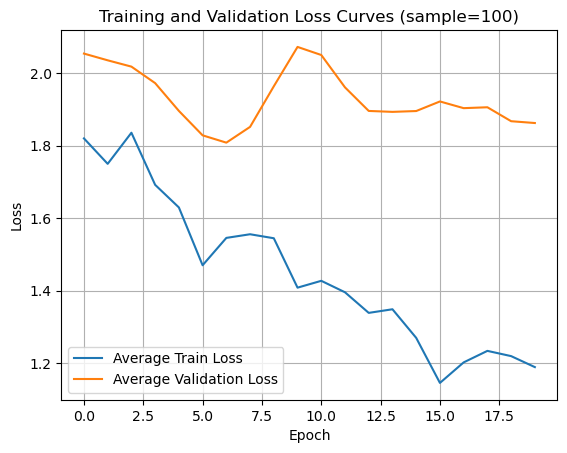

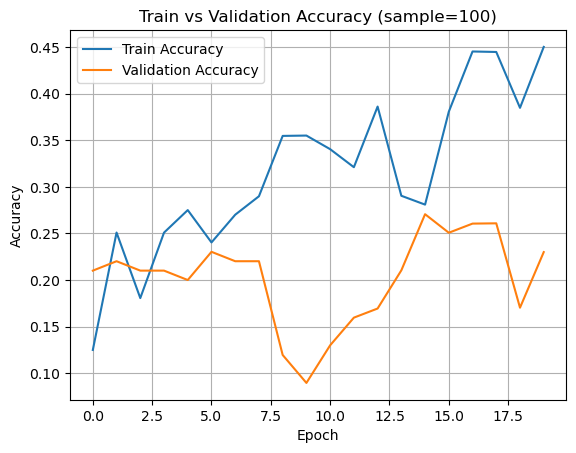

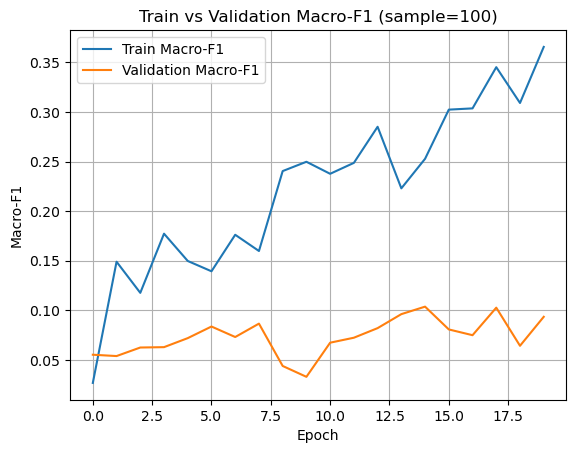

<Figure size 800x600 with 0 Axes>

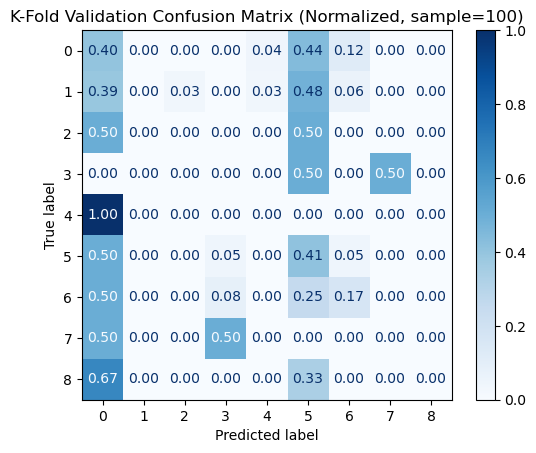

mean_val_acc: 0.21063576945929888
mean_val_f1: 0.0730822502108734

Loaded cached results for sample=500


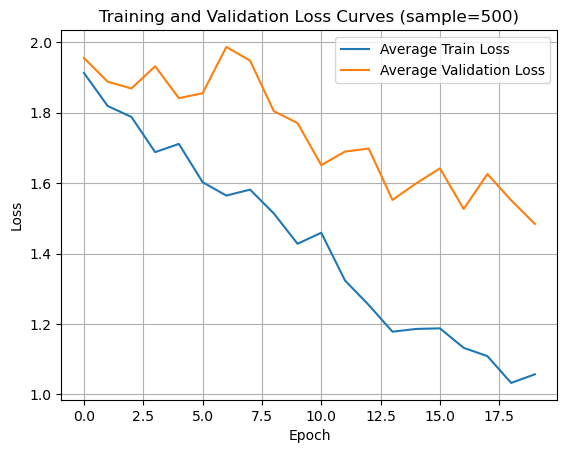

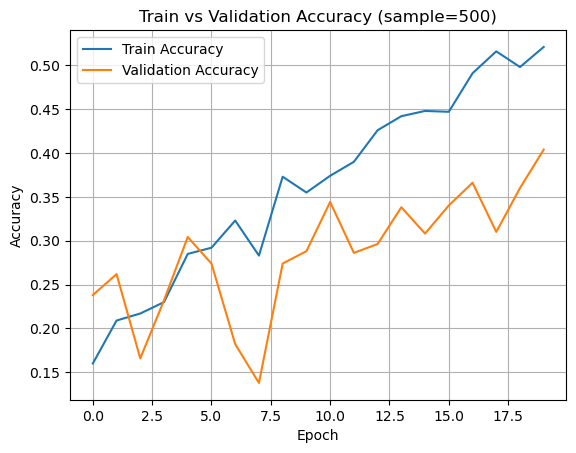

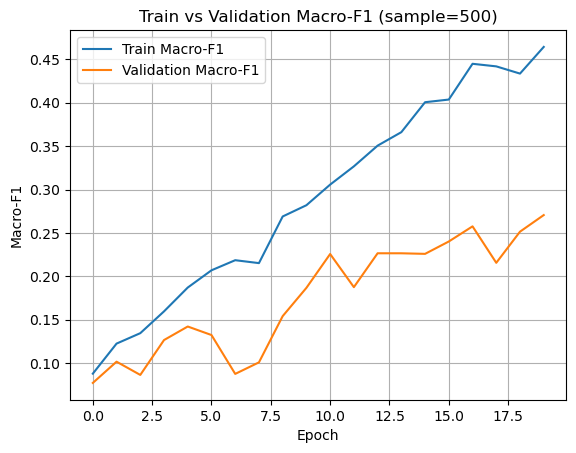

<Figure size 800x600 with 0 Axes>

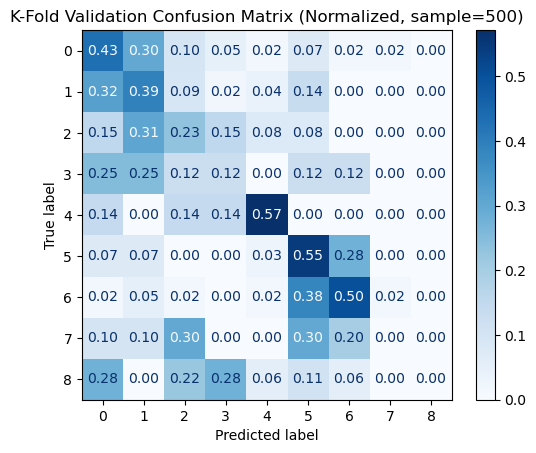

mean_val_acc: 0.4200274150494192
mean_val_f1: 0.2566939632539656

Loaded cached results for sample=990


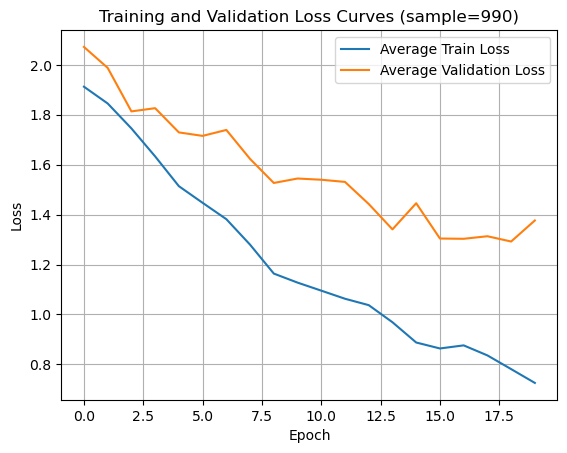

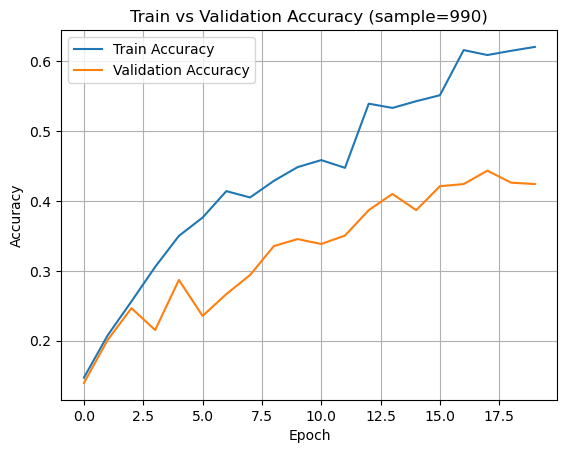

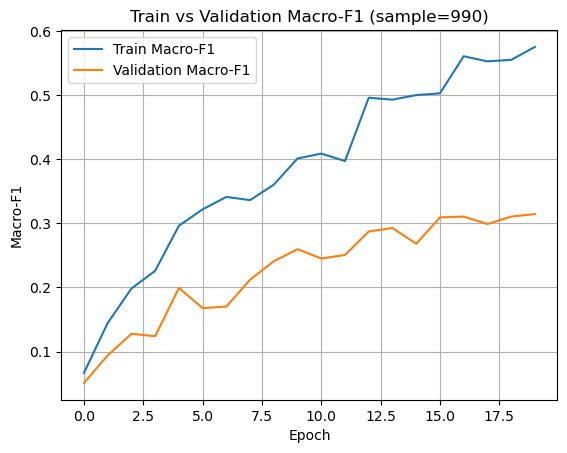

<Figure size 800x600 with 0 Axes>

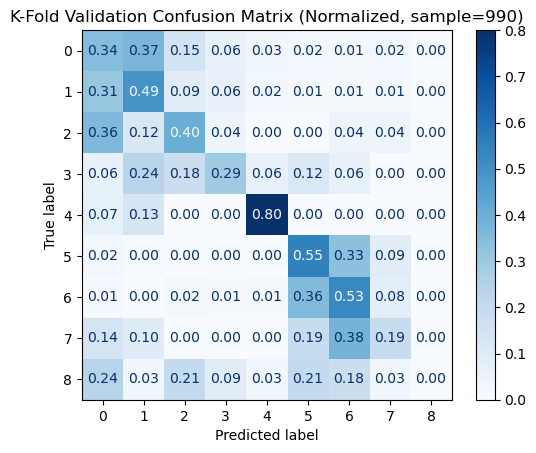

mean_val_acc: 0.44646464646464645
mean_val_f1: 0.3119957758618428


In [92]:
for sample in [100, 500, 990]:

    cache_path = f"cached_data/transformer_kfold_sample_{sample}.pkl"

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            results = pickle.load(f)
        print(f"\nLoaded cached results for sample={sample}")

    else:
        df_sample = stratified_sample_df(subset, n=sample, random_state=67)

        print(f"\nSample size = {sample}")
        print(df_sample["category"].value_counts(normalize=True).sort_index())

        tokenizer = ReactionTokenizer()
        tokenizer.build_vocab(df_sample)

        # compute the longest reaction token sequence in this sample
        max_len_seen = 0
        for _, row in df_sample.iterrows():
            tokens, _, _ = build_reaction_tokens(
                reactant_smiles=row["reactant"],
                product_smiles=row["product"],
                reactant_preds=row.get("reactant_preds", None),
                product_preds=row.get("product_preds", None),
                include_gnn_vec=True
            )
            max_len_seen = max(max_len_seen, len(tokens))

        results = KFoldCrossValidationTransformer(
            model_class=ReactionTransformer,
            df=df_sample,
            tokenizer=tokenizer,

            include_gnn_vec=True,
            k=3,
            batch_size=85,
            epochs=20,
            lr=1.5e-3,

            device="mps",
            show_progress=False,
            verbose=False,
            make_plots=False,   # disable internal plotting

            random_state=67,
            val_every=1,
            train_eval_every=1,

            use_class_weights=False,
            use_weighted_sampling=True, # DEALS WITH CLASS IMBALANCE
            gnn_dim=9,

            model_kwargs={
                "d_model": 128,
                "nhead": 2,
                "num_layers": 2,
                "dim_feedforward": 135,
                "dropout": 0.29,
                "max_len": max_len_seen + 16,
            }
        )

        os.makedirs("cached_data", exist_ok=True)
        with open(cache_path, "wb") as f:
            pickle.dump(results, f)

        print(f"Saved cached results for sample={sample}")

    # plot after load or run
    plt.figure()
    plt.plot(results["avg_train_losses"], label="Average Train Loss")
    plt.plot(results["avg_val_losses"], label="Average Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training and Validation Loss Curves (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(results["avg_train_accs"], label="Train Accuracy")
    plt.plot(results["avg_val_accs"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Train vs Validation Accuracy (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()
    plt.plot(results["avg_train_f1s"], label="Train Macro-F1")
    plt.plot(results["avg_val_f1s"], label="Validation Macro-F1")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.title(f"Train vs Validation Macro-F1 (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    cm = confusion_matrix(results["val_labels"].numpy(), results["val_preds"].numpy(), normalize="true")
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title(f"K-Fold Validation Confusion Matrix (Normalized, sample={sample})")
    plt.grid(False)
    plt.show()

    print("mean_val_acc:", results["mean_val_acc"])
    print("mean_val_f1:", results["mean_val_f1"])


Loaded cached results for sample = 200


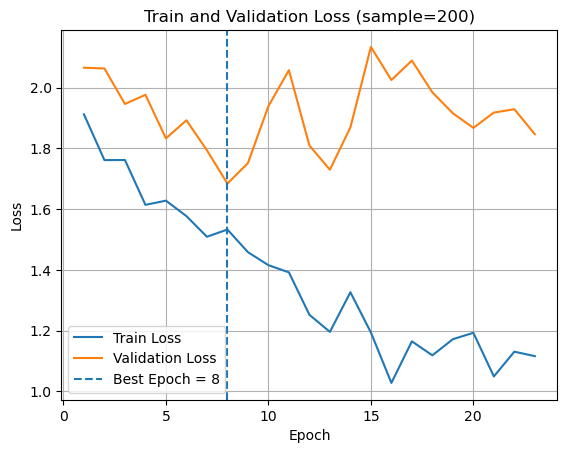

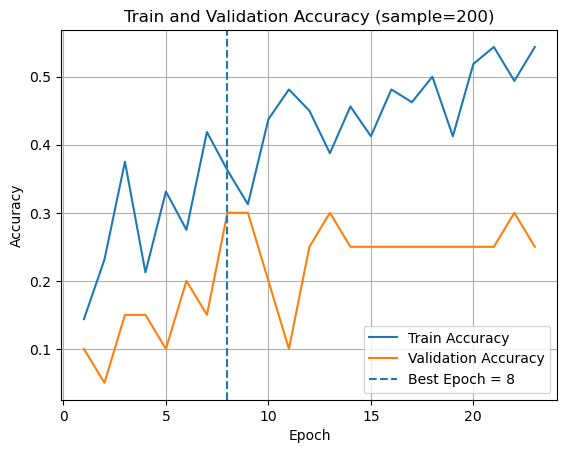

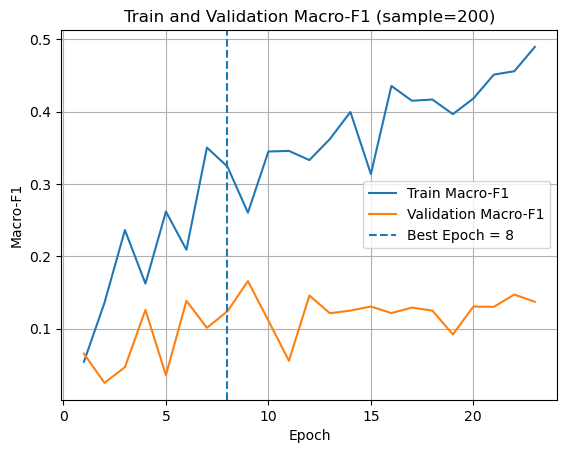

<Figure size 800x600 with 0 Axes>

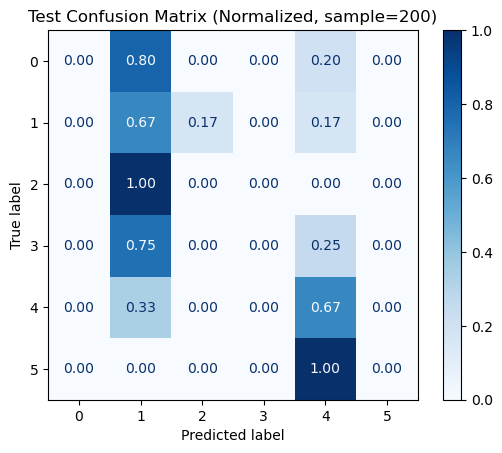

train_acc: 0.35625
val_acc: 0.3
test_acc: 0.3
train_f1: 0.28559720815039963
val_f1: 0.12406015037593984
test_f1: 0.1442495126705653

Loaded cached results for sample = 500


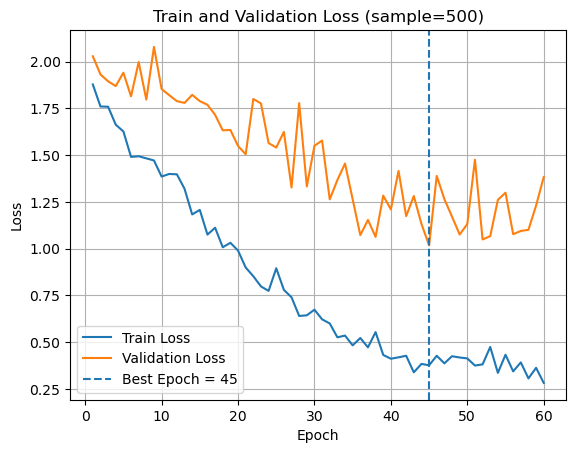

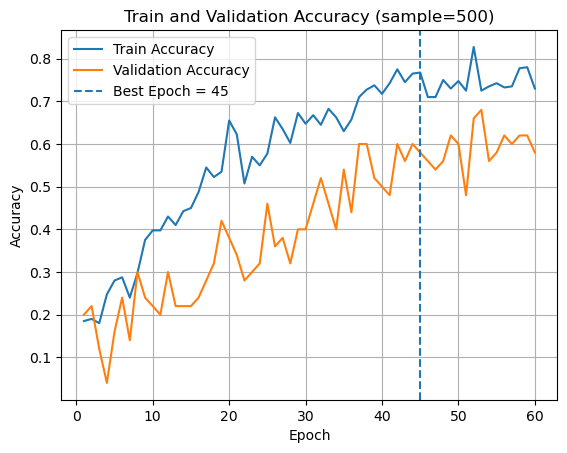

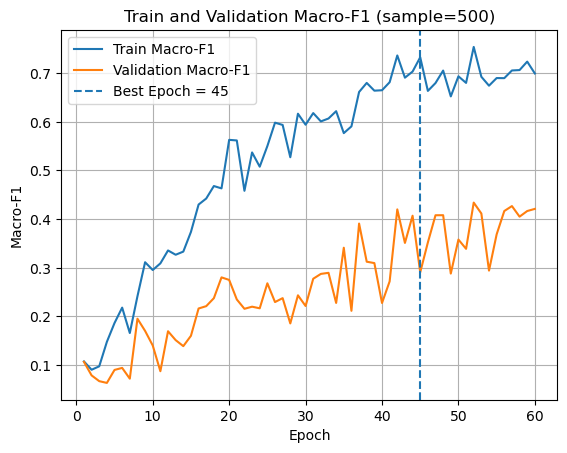

<Figure size 800x600 with 0 Axes>

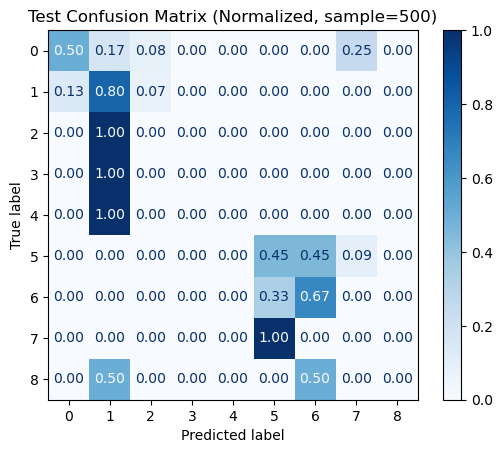

train_acc: 0.7425
val_acc: 0.58
test_acc: 0.54
train_f1: 0.7137152091716935
val_f1: 0.29066489066489065
test_f1: 0.2615098351940457

Loaded cached results for sample = 990


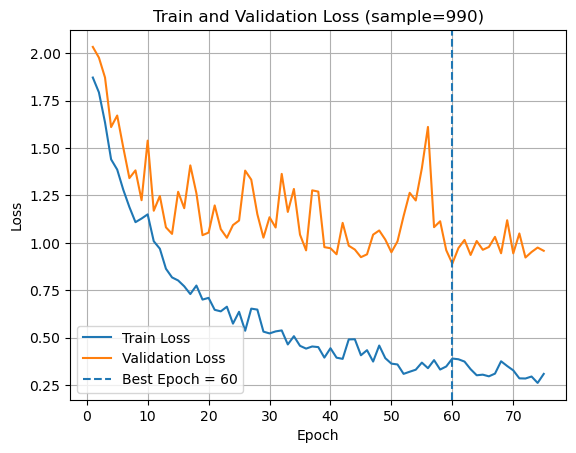

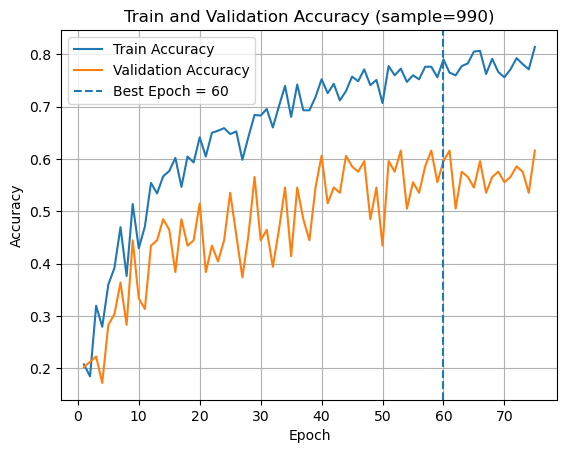

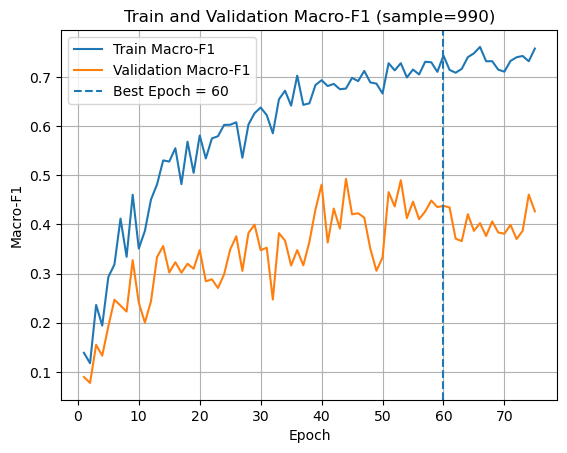

<Figure size 800x600 with 0 Axes>

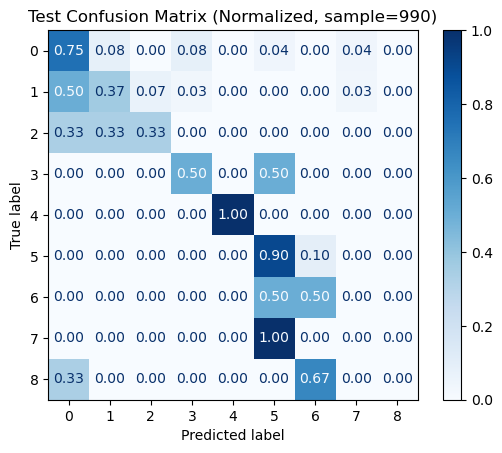

train_acc: 0.803030303030303
val_acc: 0.5959595959595959
test_acc: 0.5858585858585859
train_f1: 0.7506219515315529
val_f1: 0.4378528565726633
test_f1: 0.45358785596073736


In [93]:
for sample in [200, 500, 990]:

    cache_path = f"cached_data/transformer_trainvaltest_sample_{sample}.pkl"

    if os.path.exists(cache_path):
        with open(cache_path, "rb") as f:
            results = pickle.load(f)
        print(f"\nLoaded cached results for sample = {sample}")

    else:
        df_sample = stratified_sample_df(subset, n=sample, random_state=67)

        print(f"\nSample size = {sample}")
        print(df_sample["category"].value_counts(normalize=True).sort_index())

        # tokenizer must be built on the dataframe being used
        tokenizer = ReactionTokenizer()
        tokenizer.build_vocab(df_sample)

        # compute the longest reaction token sequence in this sample
        max_len_seen = 0
        for _, row in df_sample.iterrows():
            tokens, _, _ = build_reaction_tokens(
                reactant_smiles=row["reactant"],
                product_smiles=row["product"],
                reactant_preds=row.get("reactant_preds", None),
                product_preds=row.get("product_preds", None),
                include_gnn_vec=True
            )
            max_len_seen = max(max_len_seen, len(tokens))

        results = train_validate_test_transformer(
            model_class=ReactionTransformer,
            df=df_sample,

            tokenizer=tokenizer,
            include_gnn_vec=True,

            test_size=0.1,
            val_size=0.1,

            batch_size=85,
            epochs=80,
            lr=1.5e-3,
            optimizer=torch.optim.Adam,

            device="mps",
            random_state=67,

            show_progress=False,
            verbose=True,
            make_plots=False,   # always plot below instead

            val_every=1,
            train_eval_every=1,
            early_stopping_patience_epochs=15,

            use_class_weights=False, # WAY TOO MUCH NOISE
            use_weighted_sampling=True,

            gnn_dim=9,

            model_kwargs={
                "d_model": 128,
                "nhead": 4,
                "num_layers": 3,
                "dim_feedforward": 200,
                "dropout": 0.25,
                "max_len": max_len_seen + 16,
            }
        )

        # save results
        os.makedirs("cached_data", exist_ok=True)
        with open(cache_path, "wb") as f:
            pickle.dump(results, f)

        print(f"Saved cached results for sample = {sample}")

    # always plot after load or run
    epochs_ran = len(results["train_losses"])

    # train and validation loss
    plt.figure()
    plt.plot(range(1, epochs_ran + 1), results["train_losses"], label="Train Loss")
    plt.plot(range(1, epochs_ran + 1), results["val_losses"], label="Validation Loss")
    plt.axvline(results["best_epoch"], linestyle="--", label=f"Best Epoch = {results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train and Validation Loss (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # train and validation accuracy
    plt.figure()
    plt.plot(range(1, epochs_ran + 1), results["train_accs"], label="Train Accuracy")
    plt.plot(range(1, epochs_ran + 1), results["val_accs"], label="Validation Accuracy")
    plt.axvline(results["best_epoch"], linestyle="--", label=f"Best Epoch = {results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(f"Train and Validation Accuracy (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # train and validation macro-F1
    plt.figure()
    plt.plot(range(1, epochs_ran + 1), results["train_f1s"], label="Train Macro-F1")
    plt.plot(range(1, epochs_ran + 1), results["val_f1s"], label="Validation Macro-F1")
    plt.axvline(results["best_epoch"], linestyle="--", label=f"Best Epoch = {results['best_epoch']}")
    plt.xlabel("Epoch")
    plt.ylabel("Macro-F1")
    plt.title(f"Train and Validation Macro-F1 (sample={sample})")
    plt.legend()
    plt.grid(True)
    plt.show()

    # confusion matrix
    cm = confusion_matrix(results["test_labels"].numpy(), results["test_preds"].numpy(), normalize="true")
    plt.figure(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues", values_format=".2f")
    plt.title(f"Test Confusion Matrix (Normalized, sample={sample})")
    plt.grid(False)
    plt.show()

    print("train_acc:", results["train_acc"])
    print("val_acc:", results["val_acc"])
    print("test_acc:", results["test_acc"])

    print("train_f1:", results["train_f1"])
    print("val_f1:", results["val_f1"])
    print("test_f1:", results["test_f1"])

So, upon closer inspection it seems like the model is mixing protection and deprotection reactions, along with reductions and oxidations, and a couple other classes. It looks like for my model to work well, I should combine a few classes.

# This marks the end of Chekkpoint 4. I can run cross validation and can train it, only to clean a few kinks.

### (4) Motif Analysis

Now is the trickiest bit of code I will need to muster. From the trasnformer model, find the chemical group or the smiles string most responsible for the label aka chemical reaction. 

For instance: I select a chemical reaction that has predicted label 'protection' reaction. From the transformer, identify which smiles tokens/chemcial motifs most influenced the model's prediction as protection (the output maybe groups involved in acetal hydrolysis, or amine protection group, or whatever). 

This is qualitatively how the algorithm will work:

(1) Importance of a singular token. 

   - Mask a token and recompute the prob of label. 

   - The bigger the drop, the more vital it is. 

(2) Aggregate the top tokens and substrings. 

   - To simplify this code, we will only aggregeate the atom tokens and the chemical groups. Then, if so happen two atom tokens are adjacent, highlight the bond between them. 

(3) Map these calculated substrings to the motif in the reaction scheme on the products and reactants side.

### I can only run and make this after the I have ran the whole, big model, so ignore this for now.

In [94]:
# please now emotionally prepare yourself for the worst python
# function you will have ever seen in your life 

# this function will do the process above for one side (products or reactants)
def show_reaction_motif(
    model, 
    tokenizer, 
    row, 
    device = "cpu", 
    include_gnn_vec = True, 
    target_class = None, 
    top_k = 20, # as in give me the top 20 tokens to highlight as important
):
    
    # please note these are reactions limited to the alchemy dataset (CHONF + Cl + S)
    def is_atom(tok): 
        return (
            tok in alchemy_elements
            or tok in ["c","n","o","s"]
            or ( tok.startswith("[") and tok.endswith("]") )
        )
    
    # tokenize the smiles and then map it to the atoms
    # for example: 
    # SMILES: CC(C)
    # tokens: ["C","C","(","C",")"]
    # atom_map: [0, 1, None, 2, None]
    def tokenize_with_map(smiles): 
        mol = Chem.MolFromSmiles(smiles)
        tokens = tokenize_smiles(smiles)

        atom_map = []
        atom_idx = 0

        for tok in tokens: 
            if is_atom(tok) and atom_idx < mol.GetNumAtoms(): 
                atom_map.append(atom_idx) 
                atom_idx += 1
            else: atom_map.append(atom_idx)

        return tokens, atom_map
    
    # split the reaction into molecules
    r_smiles = [s.strip() for s in row["reactant"].split(".") if s.strip()]
    p_smiles = [s.strip() for s in row["product"].split(".") if s.strip()]

    # handle the gnn vectors
    r_preds = ensure_prediction_list(row.get("reactant_preds"))
    p_preds = ensure_prediction_list(row.get("product_preds"))


## Endgame
$\bold{\text{Using the whole alchemy and uspto dataset}}$, run the transformer by itself to see if chemical reactions are well-predicted. Then, run the GNN, couple it to the transfomer, and see if reactions are even more greatly correctly predicted!